# Data Storm 7.0 — Data-Drifters
## Bronze → Silver Pipeline (Improved)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path
import json
# import re
import time
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.neighbors import BallTree
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import warnings
import os
warnings.filterwarnings('ignore')

# import shap
# import os
from scipy.optimize import linprog
# from dotenv import load_dotenv
# ── Directory Configuration ──
DATA_PATHS = {
    'raw':             'data/',
    'bronze':          'bronze/',
    'silver':          'silver/',
    'silver_rejected': 'silver/rejected/',
    'gold':            'gold/',
}

for d in DATA_PATHS.values():
    Path(d).mkdir(parents=True, exist_ok=True)
    print(f"✓ Directory ready: {d}")

# ── Raw Data File Registry ──
RAW_FILES = {
    'transactions':             'transactions_history_final.csv',
    'outlet_master':            'outlet_master.csv',
    'outlet_coords':            'outlet_coordinates.csv',
    'distributor_seasonality':  'distributor_seasonality_details.csv',
    'holiday_list':             'holiday_list.csv',
}

# ── Domain Constants ──
OUTLET_ID_PATTERN = r'^OUT_\d{5}$'
DISTRIBUTOR_ID_PATTERN = r'^DIST_[A-Z]{1,2}_\d{2}$'
VALID_OUTLET_SIZES = {'Small', 'Medium', 'Large', 'Extra Large'}
OUTLET_TYPE_CORRECTIONS = {
    'Bakry': 'Bakery',
    'Grocry': 'Grocery',
}
SL_LAT_RANGE = (5.9, 9.9)
SL_LON_RANGE = (79.4, 82.0)
YEAR_RANGE = (2023, 2025)
MONTH_RANGE = (1, 12)
VALID_SEASONALITY = {'Favorable', 'Moderate', 'Un-Favorable'}

print(f"\n✓ Configuration loaded — {len(RAW_FILES)} datasets registered")

✓ Directory ready: data/
✓ Directory ready: bronze/
✓ Directory ready: silver/
✓ Directory ready: silver/rejected/
✓ Directory ready: gold/

✓ Configuration loaded — 5 datasets registered


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# BRONZE LAYER — Ingest every CSV as-is with zero transformations
# ══════════════════════════════════════════════════════════════════════════════

bronze = {}

for name, filename in RAW_FILES.items():
    src = f"{DATA_PATHS['raw']}{filename}"
    print(f"Ingesting {name}...")

    df = pd.read_csv(src)

    # Save pickle + CSV + sample
    df.to_pickle(f"{DATA_PATHS['bronze']}{name}.pkl")
    df.to_csv(f"{DATA_PATHS['bronze']}{name}.csv", index=False)
    df.head(1000).to_csv(f"{DATA_PATHS['bronze']}{name}_sample_1k.csv", index=False)

    meta = {
        'source_file': filename,
        'ingested_at': datetime.now().isoformat(),
        'rows': len(df),
        'columns': list(df.columns),
        'dtypes': {c: str(d) for c, d in df.dtypes.items()},
        'nulls': df.isnull().sum().to_dict(),
        'memory_mb': round(df.memory_usage(deep=True).sum() / 1024**2, 2),
    }
    bronze[name] = {'data': df, 'meta': meta}
    print(f"  ✓ {len(df):,} rows × {len(df.columns)} cols → bronze/{name}.pkl")

# Save metadata registry
with open(f"{DATA_PATHS['bronze']}ingestion_metadata.json", 'w') as f:
    json.dump({k: v['meta'] for k, v in bronze.items()}, f, indent=2, default=str)

print(f"\n{'='*70}")
print("BRONZE LAYER COMPLETE — ALL 5 DATASETS INGESTED")
print(f"{'='*70}")
for name, info in bronze.items():
    print(f"  {name:30s}  {info['meta']['rows']:>10,} rows")
print(f"{'='*70}\n")

Ingesting transactions...


  ✓ 2,376,389 rows × 7 cols → bronze/transactions.pkl
Ingesting outlet_master...
  ✓ 20,000 rows × 4 cols → bronze/outlet_master.pkl
Ingesting outlet_coords...
  ✓ 20,000 rows × 3 cols → bronze/outlet_coords.pkl
Ingesting distributor_seasonality...
  ✓ 360 rows × 4 cols → bronze/distributor_seasonality.pkl
Ingesting holiday_list...
  ✓ 349 rows × 3 cols → bronze/holiday_list.pkl

BRONZE LAYER COMPLETE — ALL 5 DATASETS INGESTED
  transactions                     2,376,389 rows
  outlet_master                       20,000 rows
  outlet_coords                       20,000 rows
  distributor_seasonality                360 rows
  holiday_list                           349 rows



In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# REUSABLE DATA QUALITY FUNCTIONS
# Every function: (df, **params) → boolean Series (True = FAILS the check)
# ══════════════════════════════════════════════════════════════════════════════

def dq_null_check(df, columns=None):
    """Flag rows where any specified column is null."""
    if columns is None:
        columns = df.columns.tolist()
    cols = [c for c in columns if c in df.columns]
    return df[cols].isnull().any(axis=1)


def dq_duplicate_check(df, key_columns):
    """Flag ALL rows sharing a duplicate composite key."""
    return df.duplicated(subset=key_columns, keep=False)


def dq_referential_integrity(df, column, valid_values):
    """Flag rows where column value is not in a reference set."""
    return ~df[column].isin(valid_values)


def dq_value_range(df, column, min_val=None, max_val=None):
    """Flag rows where a numeric column falls outside [min, max]."""
    out = pd.Series(False, index=df.index)
    if min_val is not None:
        out = out | (df[column] < min_val)
    if max_val is not None:
        out = out | (df[column] > max_val)
    return out


def dq_format_check(df, column, pattern):
    """Flag rows where a string column doesn't match regex pattern."""
    return ~df[column].astype(str).str.match(pattern)


def dq_negative_check(df, columns):
    """Flag rows where any specified column is negative."""
    cols = [c for c in columns if c in df.columns]
    return (df[cols] < 0).any(axis=1)


def dq_zero_check(df, columns):
    """Flag rows where any specified column is exactly zero."""
    cols = [c for c in columns if c in df.columns]
    return (df[cols] == 0).any(axis=1)


def dq_valid_category(df, column, valid_set):
    """Flag rows where a categorical column has unexpected values."""
    return ~df[column].isin(valid_set)


def dq_iqr_outlier(df, value_col, group_col=None, multiplier=1.5):
    """Flag IQR outliers, optionally computed per group."""
    flagged = pd.Series(False, index=df.index)
    valid = df[value_col].notna() & np.isfinite(df[value_col])

    if group_col is None:
        vals = df.loc[valid, value_col]
        q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
        iqr = q3 - q1
        flagged = valid & ((df[value_col] < q1 - multiplier*iqr) |
                           (df[value_col] > q3 + multiplier*iqr))
    else:
        for grp, gdf in df[valid].groupby(group_col):
            q1, q3 = gdf[value_col].quantile(0.25), gdf[value_col].quantile(0.75)
            iqr = q3 - q1
            lo, hi = q1 - multiplier*iqr, q3 + multiplier*iqr
            grp_mask = df[group_col].eq(grp) & valid
            flagged = flagged | (grp_mask & ((df[value_col] < lo) | (df[value_col] > hi)))
    return flagged


def dq_percentile_ceiling(df, value_col, filter_mask=None, percentile=99.9):
    """Flag rows exceeding a percentile ceiling on a filtered subset."""
    if filter_mask is None:
        filter_mask = pd.Series(True, index=df.index)
    subset = df.loc[filter_mask, value_col]
    if len(subset) == 0:
        return pd.Series(False, index=df.index)
    ceiling = subset.quantile(percentile / 100)
    return filter_mask & (df[value_col] > ceiling)


def run_dq_pipeline(df, checks, dataset_name="dataset"):
    """Execute ordered DQ checks. Returns (clean_df, rejected_df).

    Args:
        df: input DataFrame
        checks: list of (check_name, boolean_mask) in priority order
        dataset_name: for logging
    """
    print(f"\nRunning {len(checks)} DQ checks on {dataset_name}...")
    reasons = pd.Series('PASS', index=df.index)

    for name, mask in checks:
        new_flags = (mask & (reasons == 'PASS')).sum()
        reasons[mask & (reasons == 'PASS')] = name
        total = mask.sum()
        tag = f"{new_flags:,} flagged" if new_flags > 0 else "✓ clean"
        print(f"  {name:40s} {tag}")

    clean = df[reasons == 'PASS'].copy()
    rejected = df[reasons != 'PASS'].copy()
    rejected['rejection_reason'] = reasons[reasons != 'PASS']
    rejected['detected_at'] = datetime.now().isoformat()

    rate = len(clean) / len(df) * 100 if len(df) > 0 else 0
    print(f"  ── Clean: {len(clean):,} | Rejected: {len(rejected):,} | Rate: {rate:.1f}%")
    return clean, rejected


def resolve_duplicates(df, key_cols, sort_col=None, ascending=False):
    """Within clean data, keep best row per duplicate group.

    Args:
        df: clean DataFrame
        key_cols: composite key columns
        sort_col: column to sort by to pick the 'best' row (e.g. highest volume)
        ascending: sort order for picking best
    Returns:
        (deduped_df, dup_rejected_df)
    """
    dup_mask = df.duplicated(subset=key_cols, keep=False)
    n = dup_mask.sum()
    if n == 0:
        print("  ✓ No duplicates to resolve")
        return df, pd.DataFrame()

    if sort_col and sort_col in df.columns:
        keep_idx = df[dup_mask].groupby(key_cols)[sort_col].idxmax() if not ascending \
                   else df[dup_mask].groupby(key_cols)[sort_col].idxmin()
        reject_idx = df[dup_mask].index.difference(keep_idx)
    else:
        # keep first occurrence
        reject_idx = df[df.duplicated(subset=key_cols, keep='first')].index

    dup_rejected = df.loc[reject_idx].copy()
    dup_rejected['rejection_reason'] = 'DUPLICATE_RESOLVED'
    dup_rejected['detected_at'] = datetime.now().isoformat()
    deduped = df.drop(index=reject_idx)

    print(f"  Duplicates: {n:,} rows involved → kept {len(deduped) - (len(df) - n):,}, "
          f"rejected {len(reject_idx):,}")
    return deduped, dup_rejected


print("✓ DQ Framework loaded — 11 check functions + pipeline runner + dedup resolver")

✓ DQ Framework loaded — 11 check functions + pipeline runner + dedup resolver


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# SILVER: TRANSACTIONS
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nSILVER: TRANSACTIONS\n{'='*70}")

tx = pd.read_pickle(f"{DATA_PATHS['bronze']}transactions.pkl")
print(f"Loaded {len(tx):,} rows from Bronze")

# Reference sets from master tables
om_ref = pd.read_pickle(f"{DATA_PATHS['bronze']}outlet_master.pkl")
ds_ref = pd.read_pickle(f"{DATA_PATHS['bronze']}distributor_seasonality.pkl")
valid_outlets = set(om_ref['Outlet_ID'].dropna().unique())
valid_distributors = set(ds_ref['Distributor_ID'].dropna().unique())

# Compute price/liter for outlier check (guard div-by-zero)
safe_vol = tx['Volume_Liters'].replace(0, np.nan)
tx['_ppl'] = tx['Total_Bill_Value'] / safe_vol

checks = [
    # Structural
    ('NULL_VALUES',                dq_null_check(tx)),
    ('OUTLET_ID_FORMAT',           dq_format_check(tx, 'Outlet_ID', OUTLET_ID_PATTERN)),
    ('DISTRIBUTOR_ID_FORMAT',      dq_format_check(tx, 'Distributor_ID', DISTRIBUTOR_ID_PATTERN)),
    ('REF_OUTLET_INVALID',         dq_referential_integrity(tx, 'Outlet_ID', valid_outlets)),
    ('REF_DISTRIBUTOR_INVALID',    dq_referential_integrity(tx, 'Distributor_ID', valid_distributors)),
    # Value
    ('YEAR_OUT_OF_RANGE',          dq_value_range(tx, 'Year', *YEAR_RANGE)),
    ('MONTH_OUT_OF_RANGE',         dq_value_range(tx, 'Month', *MONTH_RANGE)),
    ('NEGATIVE_VALUES',            dq_negative_check(tx, ['Volume_Liters', 'Total_Bill_Value'])),
    ('ZERO_VALUES',                dq_zero_check(tx, ['Volume_Liters', 'Total_Bill_Value'])),
    # Statistical
    ('PRICE_PER_LITER_OUTLIER',    dq_iqr_outlier(tx, '_ppl', group_col='SKU_ID')),
    ('EXTREME_VOLUME_SKU06',       dq_percentile_ceiling(tx, 'Volume_Liters',
                                       filter_mask=(tx['SKU_ID'] == 'SKU_06'), percentile=99.9)),
]

clean_tx, rejected_tx = run_dq_pipeline(tx, checks, "transactions")

# Drop temp column
clean_tx = clean_tx.drop(columns=['_ppl'], errors='ignore')
rejected_tx = rejected_tx.drop(columns=['_ppl'], errors='ignore')

# Resolve duplicates — keep highest volume per group
dup_key = ['Outlet_ID', 'Year', 'Month', 'Distributor_ID', 'SKU_ID']
print("\nResolving duplicates in clean transactions...")
clean_tx, dup_rej = resolve_duplicates(clean_tx, dup_key, sort_col='Volume_Liters')
rejected_tx = pd.concat([rejected_tx, dup_rej], ignore_index=False)

# Save
clean_tx.to_pickle(f"{DATA_PATHS['silver']}transactions_clean.pkl")
clean_tx.to_csv(f"{DATA_PATHS['silver']}transactions_clean.csv", index=False)
rejected_tx.to_csv(f"{DATA_PATHS['silver_rejected']}transactions_rejected.csv", index=False)

# Assertions
assert clean_tx.isnull().sum().sum() == 0, "Nulls in clean tx!"
assert ~clean_tx.duplicated(subset=dup_key).any(), "Duplicates in clean tx!"
assert (clean_tx['Volume_Liters'] > 0).all(), "Non-positive volumes!"
assert (clean_tx['Total_Bill_Value'] > 0).all(), "Non-positive bills!"
print("✓ All post-cleaning assertions passed")

print(f"\n{'='*70}")
print(f"TRANSACTIONS: {len(tx):,} → Clean: {len(clean_tx):,} | "
      f"Rejected: {len(rejected_tx):,} | Rate: {len(clean_tx)/len(tx)*100:.1f}%")
print(f"{'='*70}")


SILVER: TRANSACTIONS
Loaded 2,376,389 rows from Bronze

Running 11 DQ checks on transactions...
  NULL_VALUES                              100 flagged
  OUTLET_ID_FORMAT                         ✓ clean
  DISTRIBUTOR_ID_FORMAT                    ✓ clean
  REF_OUTLET_INVALID                       ✓ clean
  REF_DISTRIBUTOR_INVALID                  ✓ clean
  YEAR_OUT_OF_RANGE                        ✓ clean
  MONTH_OUT_OF_RANGE                       ✓ clean
  NEGATIVE_VALUES                          4,753 flagged
  ZERO_VALUES                              ✓ clean
  PRICE_PER_LITER_OUTLIER                  272,135 flagged
  EXTREME_VOLUME_SKU06                     232 flagged
  ── Clean: 2,099,169 | Rejected: 277,220 | Rate: 88.3%

Resolving duplicates in clean transactions...
  Duplicates: 22,363 rows involved → kept 10,947, rejected 11,416
✓ All post-cleaning assertions passed

TRANSACTIONS: 2,376,389 → Clean: 2,087,753 | Rejected: 288,636 | Rate: 87.9%


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# SILVER: OUTLET MASTER
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nSILVER: OUTLET MASTER\n{'='*70}")

om = pd.read_pickle(f"{DATA_PATHS['bronze']}outlet_master.pkl")
print(f"Loaded {len(om):,} rows | Columns: {list(om.columns)}")

# ── Normalize dirty string values (data forensics) ──
# Strip whitespace from all string columns
for col in om.select_dtypes(include='object').columns:
    om[col] = om[col].astype(str).str.strip()

# Fix known Outlet_Type typos
om['Outlet_Type'] = om['Outlet_Type'].replace(OUTLET_TYPE_CORRECTIONS)
print(f"  ✓ Outlet_Type corrected: {OUTLET_TYPE_CORRECTIONS}")

# Normalize Outlet_Size casing (e.g. 'small' → 'Small')
om['Outlet_Size'] = om['Outlet_Size'].str.title()
print(f"  ✓ Outlet_Size casing normalized")
print(f"  Outlet_Type values: {om['Outlet_Type'].value_counts().to_dict()}")
print(f"  Outlet_Size values: {om['Outlet_Size'].value_counts().to_dict()}")

checks = [
    ('NULL_VALUES',        dq_null_check(om)),
    ('OUTLET_ID_FORMAT',   dq_format_check(om, 'Outlet_ID', OUTLET_ID_PATTERN)),
    ('DUPLICATE_OUTLET',   dq_duplicate_check(om, ['Outlet_ID'])),
    ('INVALID_OUTLET_SIZE', dq_valid_category(om, 'Outlet_Size', VALID_OUTLET_SIZES)),
    ('NEGATIVE_COOLERS',   dq_value_range(om, 'Cooler_Count', min_val=0)),
]

clean_om, rejected_om = run_dq_pipeline(om, checks, "outlet_master")

# Resolve duplicates
print("Resolving duplicates...")
clean_om, dup_rej = resolve_duplicates(clean_om, ['Outlet_ID'])
rejected_om = pd.concat([rejected_om, dup_rej], ignore_index=False)

# Save
clean_om.to_pickle(f"{DATA_PATHS['silver']}outlet_master.pkl")
clean_om.to_csv(f"{DATA_PATHS['silver']}outlet_master.csv", index=False)
rejected_om.to_csv(f"{DATA_PATHS['silver_rejected']}outlet_master_rejected.csv", index=False)

print(f"Outlet Master: {len(om):,} → Clean: {len(clean_om):,} | Rejected: {len(rejected_om):,}")


SILVER: OUTLET MASTER
Loaded 20,000 rows | Columns: ['Outlet_ID', 'Outlet_Size', 'Cooler_Count', 'Outlet_Type']
  ✓ Outlet_Type corrected: {'Bakry': 'Bakery', 'Grocry': 'Grocery'}
  ✓ Outlet_Size casing normalized
  Outlet_Type values: {'Grocery': 3158, 'Bakery': 3073, 'Eatery': 2867, 'Hotel': 2797, 'SMMT': 2723, 'Pharmacy': 2691, 'Kiosk': 2691}
  Outlet_Size values: {'Small': 10272, 'Medium': 5702, 'Large': 2887, 'Extra Large': 943, 'Nan': 196}

Running 5 DQ checks on outlet_master...
  NULL_VALUES                              ✓ clean
  OUTLET_ID_FORMAT                         ✓ clean
  DUPLICATE_OUTLET                         ✓ clean
  INVALID_OUTLET_SIZE                      196 flagged
  NEGATIVE_COOLERS                         ✓ clean
  ── Clean: 19,804 | Rejected: 196 | Rate: 99.0%
Resolving duplicates...
  ✓ No duplicates to resolve
Outlet Master: 20,000 → Clean: 19,804 | Rejected: 196


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# SILVER: OUTLET COORDINATES
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nSILVER: OUTLET COORDINATES\n{'='*70}")

oc = pd.read_pickle(f"{DATA_PATHS['bronze']}outlet_coords.pkl")
print(f"Loaded {len(oc):,} rows | Columns: {list(oc.columns)}")

# Valid outlets from clean outlet master
valid_outlet_ids = set(clean_om['Outlet_ID'].unique())

checks = [
    ('NULL_VALUES',              dq_null_check(oc)),
    ('OUTLET_ID_FORMAT',         dq_format_check(oc, 'Outlet_ID', OUTLET_ID_PATTERN)),
    ('DUPLICATE_OUTLET',         dq_duplicate_check(oc, ['Outlet_ID'])),
    ('REF_OUTLET_NOT_IN_MASTER', dq_referential_integrity(oc, 'Outlet_ID', valid_outlet_ids)),
    ('LATITUDE_OUT_OF_RANGE',    dq_value_range(oc, 'Latitude', *SL_LAT_RANGE)),
    ('LONGITUDE_OUT_OF_RANGE',   dq_value_range(oc, 'Longitude', *SL_LON_RANGE)),
]

clean_oc, rejected_oc = run_dq_pipeline(oc, checks, "outlet_coordinates")

print("Resolving duplicates...")
clean_oc, dup_rej = resolve_duplicates(clean_oc, ['Outlet_ID'])
rejected_oc = pd.concat([rejected_oc, dup_rej], ignore_index=False)

clean_oc.to_pickle(f"{DATA_PATHS['silver']}outlet_coordinates.pkl")
clean_oc.to_csv(f"{DATA_PATHS['silver']}outlet_coordinates.csv", index=False)
rejected_oc.to_csv(f"{DATA_PATHS['silver_rejected']}outlet_coordinates_rejected.csv", index=False)

print(f"Outlet Coords: {len(oc):,} → Clean: {len(clean_oc):,} | Rejected: {len(rejected_oc):,}")


SILVER: OUTLET COORDINATES
Loaded 20,000 rows | Columns: ['Outlet_ID', 'Latitude', 'Longitude']

Running 6 DQ checks on outlet_coordinates...
  NULL_VALUES                              ✓ clean
  OUTLET_ID_FORMAT                         ✓ clean
  DUPLICATE_OUTLET                         ✓ clean
  REF_OUTLET_NOT_IN_MASTER                 196 flagged
  LATITUDE_OUT_OF_RANGE                    240 flagged
  LONGITUDE_OUT_OF_RANGE                   ✓ clean
  ── Clean: 19,564 | Rejected: 436 | Rate: 97.8%
Resolving duplicates...
  ✓ No duplicates to resolve
Outlet Coords: 20,000 → Clean: 19,564 | Rejected: 436


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# SILVER: DISTRIBUTOR SEASONALITY
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nSILVER: DISTRIBUTOR SEASONALITY\n{'='*70}")

ds = pd.read_pickle(f"{DATA_PATHS['bronze']}distributor_seasonality.pkl")
print(f"Loaded {len(ds):,} rows | Columns: {list(ds.columns)}")

# Note: dataset has Year column (10 distributors × 12 months × 3 years = 360 rows)
# Composite key must include Year to avoid false duplicate flags
dup_key_ds = ['Distributor_ID', 'Year', 'Month']

checks = [
    ('NULL_VALUES',              dq_null_check(ds)),
    ('DISTRIBUTOR_ID_FORMAT',    dq_format_check(ds, 'Distributor_ID', DISTRIBUTOR_ID_PATTERN)),
    ('DUPLICATE_ENTRY',          dq_duplicate_check(ds, dup_key_ds)),
    ('MONTH_OUT_OF_RANGE',       dq_value_range(ds, 'Month', *MONTH_RANGE)),
    ('INVALID_SEASONALITY',      dq_valid_category(ds, 'Seasonality_Index', VALID_SEASONALITY)),
]

clean_ds, rejected_ds = run_dq_pipeline(ds, checks, "distributor_seasonality")

print("Resolving duplicates...")
clean_ds, dup_rej = resolve_duplicates(clean_ds, dup_key_ds)
rejected_ds = pd.concat([rejected_ds, dup_rej], ignore_index=False)

clean_ds.to_pickle(f"{DATA_PATHS['silver']}distributor_seasonality.pkl")
clean_ds.to_csv(f"{DATA_PATHS['silver']}distributor_seasonality.csv", index=False)
rejected_ds.to_csv(f"{DATA_PATHS['silver_rejected']}distributor_seasonality_rejected.csv", index=False)

print(f"Distributor Seasonality: {len(ds):,} → Clean: {len(clean_ds):,} | Rejected: {len(rejected_ds):,}")


SILVER: DISTRIBUTOR SEASONALITY
Loaded 360 rows | Columns: ['Distributor_ID', 'Year', 'Month', 'Seasonality_Index']

Running 5 DQ checks on distributor_seasonality...
  NULL_VALUES                              ✓ clean
  DISTRIBUTOR_ID_FORMAT                    ✓ clean
  DUPLICATE_ENTRY                          ✓ clean
  MONTH_OUT_OF_RANGE                       ✓ clean
  INVALID_SEASONALITY                      ✓ clean
  ── Clean: 360 | Rejected: 0 | Rate: 100.0%
Resolving duplicates...
  ✓ No duplicates to resolve
Distributor Seasonality: 360 → Clean: 360 | Rejected: 0


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# SILVER: HOLIDAY LIST
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nSILVER: HOLIDAY LIST\n{'='*70}")

hol = pd.read_pickle(f"{DATA_PATHS['bronze']}holiday_list.pkl")
print(f"Loaded {len(hol):,} rows | Columns: {list(hol.columns)}")

# Normalize column names
hol.columns = [c.strip() for c in hol.columns]

# Detect date and name columns heuristically
date_col = next((c for c in hol.columns if 'date' in c.lower()), hol.columns[0])
name_col = next((c for c in hol.columns if 'name' in c.lower() or 'holiday' in c.lower()), None)
if name_col is None:
    text_cols = [c for c in hol.columns if hol[c].dtype == object]
    name_col = text_cols[0] if text_cols else hol.columns[0]

print(f"  Date column: '{date_col}' | Name column: '{name_col}'")

# Parse dates for validation (strip timezone if present to avoid tz-naive vs tz-aware errors)
hol['_parsed_date'] = pd.to_datetime(hol[date_col], errors='coerce', utc=True)
hol['_parsed_date'] = hol['_parsed_date'].dt.tz_localize(None)

# Use keep='first' so only the duplicate copies are flagged, not the original row
original_cols = [c for c in hol.columns if c != '_parsed_date']

checks = [
    ('NULL_DATE',     hol['_parsed_date'].isna()),
    ('EMPTY_NAME',    hol[name_col].astype(str).str.strip().eq('')),
    ('FULL_ROW_DUP',  hol[original_cols].duplicated(keep='first')),
    ('DATE_OUT_OF_RANGE', dq_value_range(hol, '_parsed_date',
                            min_val=pd.Timestamp('2023-01-01'),
                            max_val=pd.Timestamp('2026-12-31'))),
]

clean_hol, rejected_hol = run_dq_pipeline(hol, checks, "holiday_list")

# Resolve any remaining duplicates
print("Resolving duplicates...")
clean_hol, dup_rej = resolve_duplicates(clean_hol, original_cols)
rejected_hol = pd.concat([rejected_hol, dup_rej], ignore_index=False)

# Drop temp column
clean_hol = clean_hol.drop(columns=['_parsed_date'], errors='ignore')
rejected_hol = rejected_hol.drop(columns=['_parsed_date'], errors='ignore')

clean_hol.to_pickle(f"{DATA_PATHS['silver']}holiday_list.pkl")
clean_hol.to_csv(f"{DATA_PATHS['silver']}holiday_list.csv", index=False)
rejected_hol.to_csv(f"{DATA_PATHS['silver_rejected']}holiday_list_rejected.csv", index=False)

print(f"Holiday List: {len(hol):,} → Clean: {len(clean_hol):,} | Rejected: {len(rejected_hol):,}")


SILVER: HOLIDAY LIST
Loaded 349 rows | Columns: ['Date', 'Holiday_Name', 'Holiday_Type']
  Date column: 'Date' | Name column: 'Holiday_Name'

Running 4 DQ checks on holiday_list...
  NULL_DATE                                ✓ clean
  EMPTY_NAME                               ✓ clean
  FULL_ROW_DUP                             93 flagged
  DATE_OUT_OF_RANGE                        ✓ clean
  ── Clean: 256 | Rejected: 93 | Rate: 73.4%
Resolving duplicates...
  ✓ No duplicates to resolve
Holiday List: 349 → Clean: 256 | Rejected: 93


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# SILVER LAYER SUMMARY
# ══════════════════════════════════════════════════════════════════════════════

silver_summary = {
    'Transactions':     (len(tx), len(clean_tx), len(rejected_tx)),
    'Outlet Master':    (len(om), len(clean_om), len(rejected_om)),
    'Outlet Coords':    (len(oc), len(clean_oc), len(rejected_oc)),
    'Distributor Seas': (len(ds), len(clean_ds), len(rejected_ds)),
    'Holiday List':     (len(hol), len(clean_hol), len(rejected_hol)),
}

print(f"\n{'='*70}")
print("SILVER LAYER — COMPLETE SUMMARY")
print(f"{'='*70}")
print(f"{'Dataset':25s} {'Bronze':>12s} {'Clean':>12s} {'Rejected':>12s} {'Rate':>8s}")
print(f"{'-'*70}")
for name, (inp, cln, rej) in silver_summary.items():
    rate = cln / inp * 100 if inp > 0 else 0
    print(f"{name:25s} {inp:>12,} {cln:>12,} {rej:>12,} {rate:>7.1f}%")
print(f"{'='*70}")

total_in = sum(v[0] for v in silver_summary.values())
total_clean = sum(v[1] for v in silver_summary.values())
total_rej = sum(v[2] for v in silver_summary.values())
print(f"{'TOTAL':25s} {total_in:>12,} {total_clean:>12,} {total_rej:>12,} "
      f"{total_clean/total_in*100:>7.1f}%")
print(f"{'='*70}")


SILVER LAYER — COMPLETE SUMMARY
Dataset                         Bronze        Clean     Rejected     Rate
----------------------------------------------------------------------
Transactions                 2,376,389    2,087,753      288,636    87.9%
Outlet Master                   20,000       19,804          196    99.0%
Outlet Coords                   20,000       19,564          436    97.8%
Distributor Seas                   360          360            0   100.0%
Holiday List                       349          256           93    73.4%
TOTAL                        2,417,098    2,127,737      289,361    88.0%


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# GOLD LAYER — Feature Engineering
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nGOLD LAYER — FEATURE ENGINEERING\n{'='*70}")

# Load all Silver datasets
tx_s      = pd.read_pickle(f"{DATA_PATHS['silver']}transactions_clean.pkl")
master_s  = pd.read_pickle(f"{DATA_PATHS['silver']}outlet_master.pkl")
coords_s  = pd.read_pickle(f"{DATA_PATHS['silver']}outlet_coordinates.pkl")
seas_s    = pd.read_pickle(f"{DATA_PATHS['silver']}distributor_seasonality.pkl")
hols_s    = pd.read_pickle(f"{DATA_PATHS['silver']}holiday_list.pkl")

print(f"  Transactions:  {len(tx_s):,} rows")
print(f"  Outlet Master: {len(master_s):,} rows")
print(f"  Coordinates:   {len(coords_s):,} rows")
print(f"  Seasonality:   {len(seas_s):,} rows")
print(f"  Holidays:      {len(hols_s):,} rows")

# Verify no duplicate keys in dimension tables
assert master_s['Outlet_ID'].is_unique, "Outlet Master has duplicate Outlet_IDs!"
assert coords_s['Outlet_ID'].is_unique, "Coordinates has duplicate Outlet_IDs!"
print("\n✓ Dimension table uniqueness verified")


GOLD LAYER — FEATURE ENGINEERING
  Transactions:  2,087,753 rows
  Outlet Master: 19,804 rows
  Coordinates:   19,564 rows
  Seasonality:   360 rows
  Holidays:      256 rows

✓ Dimension table uniqueness verified


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 1: Aggregate transactions to one row per outlet
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nSTEP 1: Transaction Aggregates\n{'='*70}")

# STAGE 1: Collapse to monthly totals per outlet first
# Raw data is at (Outlet_ID, Year, Month, Distributor_ID, SKU_ID) granularity
# We need monthly totals before computing avg/max/std
monthly = tx_s.groupby(['Outlet_ID', 'Year', 'Month']).agg(
    monthly_volume = ('Volume_Liters', 'sum'),
    monthly_bill   = ('Total_Bill_Value', 'sum'),
    sku_count      = ('SKU_ID', 'nunique'),
).reset_index()

print(f"  Stage 1: {len(tx_s):,} raw rows → {len(monthly):,} outlet-month rows")

# STAGE 2: Aggregate monthly totals to one row per outlet
tx_agg = monthly.groupby('Outlet_ID').agg(
    avg_monthly_volume  = ('monthly_volume', 'mean'),
    max_monthly_volume  = ('monthly_volume', 'max'),
    std_monthly_volume  = ('monthly_volume', 'std'),
    total_volume        = ('monthly_volume', 'sum'),
    avg_bill_value      = ('monthly_bill', 'mean'),
    active_months       = ('monthly_volume', 'count'),
    avg_sku_breadth     = ('sku_count', 'mean'),
).reset_index()

# Additional features from raw data
tx_extra = tx_s.groupby('Outlet_ID').agg(
    unique_skus         = ('SKU_ID', 'nunique'),
    transaction_count   = ('Volume_Liters', 'count'),
).reset_index()
tx_agg = tx_agg.merge(tx_extra, on='Outlet_ID', how='left')

# Fill NaN std (outlets with only 1 month of data)
tx_agg['std_monthly_volume'] = tx_agg['std_monthly_volume'].fillna(0)

print(f"  Stage 2: {len(tx_agg):,} unique outlets")
print(f"  avg_monthly_volume — median: {tx_agg['avg_monthly_volume'].median():.1f}, "
      f"mean: {tx_agg['avg_monthly_volume'].mean():.1f}")


STEP 1: Transaction Aggregates
  Stage 1: 2,087,753 raw rows → 423,688 outlet-month rows
  Stage 2: 20,000 unique outlets
  avg_monthly_volume — median: 45.2, mean: 204.0


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 2: Compute censorship/constraint indicators
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nSTEP 2: Censorship Indicators\n{'='*70}")

# Censorship ratio: max/mean — close to 1.0 = likely hitting a ceiling every month
tx_agg['censorship_ratio'] = (
    tx_agg['max_monthly_volume'] / tx_agg['avg_monthly_volume'].replace(0, np.nan)
).fillna(1.0)

# Coefficient of variation: std/mean — close to 0 = unnaturally stable = constrained
tx_agg['coeff_of_variation'] = (
    tx_agg['std_monthly_volume'] / tx_agg['avg_monthly_volume'].replace(0, np.nan)
).fillna(0.0)

# Summary
print(f"  censorship_ratio  — median: {tx_agg['censorship_ratio'].median():.2f}, "
      f"mean: {tx_agg['censorship_ratio'].mean():.2f}")
print(f"  coeff_of_variation — median: {tx_agg['coeff_of_variation'].median():.2f}, "
      f"mean: {tx_agg['coeff_of_variation'].mean():.2f}")

# Flag constrained outlets using data-driven threshold (10th percentile)
# rather than a hard cutoff — lets the distribution define "low"
cr_p10 = tx_agg['censorship_ratio'].quantile(0.10)
tx_agg['is_constrained'] = (tx_agg['censorship_ratio'] <= cr_p10).astype(int)

low_cr = tx_agg['is_constrained'].sum()
print(f"  Constrained threshold (10th pctile): {cr_p10:.2f}")
print(f"  Outlets flagged as constrained: {low_cr:,} ({low_cr/len(tx_agg)*100:.1f}%)")


STEP 2: Censorship Indicators
  censorship_ratio  — median: 2.57, mean: 2.75
  coeff_of_variation — median: 0.73, mean: 0.75
  Constrained threshold (10th pctile): 1.65
  Outlets flagged as constrained: 2,000 (10.0%)


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 3: Trend features — recent vs older performance
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nSTEP 3: Trend Features\n{'='*70}")

# Use the monthly table (already computed in Step 1) for proper trend analysis
monthly['_time_key'] = monthly['Year'] * 100 + monthly['Month']
median_time = monthly['_time_key'].median()

# Recent = second half, Older = first half (based on monthly totals)
recent = monthly[monthly['_time_key'] >= median_time].groupby('Outlet_ID')['monthly_volume'].mean()
older  = monthly[monthly['_time_key'] <  median_time].groupby('Outlet_ID')['monthly_volume'].mean()

trend_df = pd.DataFrame({'Outlet_ID': tx_agg['Outlet_ID']}).set_index('Outlet_ID')
trend_df['recent_avg'] = recent
trend_df['older_avg']  = older
trend_df = trend_df.fillna(0)

# Growth ratio: >1 = growing, <1 = declining
trend_df['growth_ratio'] = (
    trend_df['recent_avg'] / trend_df['older_avg'].replace(0, np.nan)
).fillna(1.0).clip(0.1, 10.0)

trend_df = trend_df.reset_index()
tx_agg = tx_agg.merge(trend_df, on='Outlet_ID', how='left')

print(f"  ✓ Trend features computed (from monthly totals)")
print(f"  growth_ratio — median: {tx_agg['growth_ratio'].median():.2f}, "
      f"mean: {tx_agg['growth_ratio'].mean():.2f}")
growing = (tx_agg['growth_ratio'] > 1.05).sum()
declining = (tx_agg['growth_ratio'] < 0.95).sum()
print(f"  Growing outlets (>1.05): {growing:,} | Declining (<0.95): {declining:,}")


STEP 3: Trend Features


  ✓ Trend features computed (from monthly totals)
  growth_ratio — median: 1.02, mean: 1.13
  Growing outlets (>1.05): 8,916 | Declining (<0.95): 7,425


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 4: Identify most recent distributor per outlet (for seasonality join)
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nSTEP 4: Most Recent Distributor\n{'='*70}")

tx_dist = (
    tx_s.sort_values(['Year', 'Month'], ascending=False)
        .drop_duplicates('Outlet_ID')[['Outlet_ID', 'Distributor_ID']]
)

tx_agg = tx_agg.merge(tx_dist, on='Outlet_ID', how='left')
print(f"  ✓ Distributor assigned to {tx_agg['Distributor_ID'].notna().sum():,} outlets")
print(f"  Distribution:\n{tx_agg['Distributor_ID'].value_counts().to_string()}")


STEP 4: Most Recent Distributor
  ✓ Distributor assigned to 20,000 outlets
  Distribution:
Distributor_ID
DIST_W_01     3020
DIST_W_03     2991
DIST_W_02     2989
DIST_NW_01    2015
DIST_NW_02    1985
DIST_S_01     1505
DIST_S_02     1495
DIST_C_01     1385
DIST_C_02     1319
DIST_C_03     1296


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 5: Merge outlet master (type, size, coolers)
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nSTEP 5: Merge Outlet Master\n{'='*70}")

n_before = len(tx_agg)

# Numeric encoding of outlet size
master_s['size_score'] = master_s['Outlet_Size'].map({
    'Small': 1, 'Medium': 2, 'Large': 3, 'Extra Large': 4
})

tx_agg = tx_agg.merge(master_s, on='Outlet_ID', how='left')

assert len(tx_agg) == n_before, \
    f"Row count changed after master merge! {n_before} → {len(tx_agg)}"
print(f"  ✓ Merged — {tx_agg['Outlet_Type'].notna().sum():,} outlets matched")
print(f"  Outlet types: {tx_agg['Outlet_Type'].value_counts().to_dict()}")
print(f"  Outlet sizes: {tx_agg['Outlet_Size'].value_counts().to_dict()}")


STEP 5: Merge Outlet Master
  ✓ Merged — 19,804 outlets matched
  Outlet types: {'Grocery': 3126, 'Bakery': 3039, 'Eatery': 2832, 'Hotel': 2772, 'SMMT': 2697, 'Pharmacy': 2670, 'Kiosk': 2668}
  Outlet sizes: {'Small': 10272, 'Medium': 5702, 'Large': 2887, 'Extra Large': 943}


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 6: Merge coordinates (lat/lon)
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nSTEP 6: Merge Coordinates\n{'='*70}")

n_before = len(tx_agg)
tx_agg = tx_agg.merge(coords_s, on='Outlet_ID', how='left')

assert len(tx_agg) == n_before, \
    f"Row count changed after coords merge! {n_before} → {len(tx_agg)}"
print(f"  ✓ Merged — {tx_agg['Latitude'].notna().sum():,} outlets have coordinates")


STEP 6: Merge Coordinates
  ✓ Merged — 19,564 outlets have coordinates


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 7: January 2026 seasonality adjustment per distributor
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nSTEP 7: January Seasonality Score\n{'='*70}")

# Average seasonality across ALL available January data (not just latest year)
# This gives a more stable estimate per distributor
SEAS_MAP = {'Favorable': 1.20, 'Moderate': 1.00, 'Un-Favorable': 0.85}
jan_seas = seas_s[(seas_s['Month'] == 1)].copy()
jan_seas['_score'] = jan_seas['Seasonality_Index'].map(SEAS_MAP)

# Average across years per distributor
jan_avg = jan_seas.groupby('Distributor_ID')['_score'].mean().reset_index()
jan_avg.columns = ['Distributor_ID', 'jan_seasonality_score']

print(f"  January seasonality per distributor (averaged across {jan_seas['Year'].nunique()} years):")
for _, row in jan_avg.iterrows():
    print(f"    {row['Distributor_ID']:15s} → {row['jan_seasonality_score']:.2f}")

n_before = len(tx_agg)
tx_agg = tx_agg.merge(jan_avg, on='Distributor_ID', how='left')
tx_agg['jan_seasonality_score'] = tx_agg['jan_seasonality_score'].fillna(1.0)

assert len(tx_agg) == n_before, \
    f"Row count changed after seasonality merge! {n_before} → {len(tx_agg)}"

# Since only 2 distinct values exist (1.0 and 1.2), convert to binary flag
# for cleaner signal — the continuous score adds no extra information
tx_agg['is_favorable_jan'] = (tx_agg['jan_seasonality_score'] > 1.0).astype(int)
print(f"  ✓ is_favorable_jan: {tx_agg['is_favorable_jan'].value_counts().to_dict()}")
print(f"  jan_seasonality_score kept for adjustment formula")


STEP 7: January Seasonality Score
  January seasonality per distributor (averaged across 3 years):
    DIST_C_01       → 1.00
    DIST_C_02       → 1.00
    DIST_C_03       → 1.00
    DIST_NW_01      → 1.00
    DIST_NW_02      → 1.00
    DIST_S_01       → 1.20
    DIST_S_02       → 1.20
    DIST_W_01       → 1.00
    DIST_W_02       → 1.00
    DIST_W_03       → 1.00
  ✓ is_favorable_jan: {0: 17000, 1: 3000}
  jan_seasonality_score kept for adjustment formula


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 8: January holiday count (use Jan 2025 as proxy — no 2026 data exists)
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nSTEP 8: January Holiday Count\n{'='*70}")

hol_dates = pd.to_datetime(hols_s.iloc[:, 0], errors='coerce', utc=True).dt.tz_localize(None)

# Try 2026 first, fall back to 2025
jan_hols = hol_dates[(hol_dates.dt.year == 2026) & (hol_dates.dt.month == 1)]
if len(jan_hols) == 0:
    jan_hols = hol_dates[(hol_dates.dt.year == 2025) & (hol_dates.dt.month == 1)]
    print(f"  ⚠ No Jan 2026 holidays found — using Jan 2025 as proxy")

tx_agg['jan_holiday_count'] = len(jan_hols.dt.date.unique())
print(f"  ✓ {tx_agg['jan_holiday_count'].iloc[0]} unique holiday dates in January")
if len(jan_hols) > 0:
    print(f"  Dates: {sorted([str(d) for d in jan_hols.dt.date.unique()])}")


STEP 8: January Holiday Count
  ⚠ No Jan 2026 holidays found — using Jan 2025 as proxy
  ✓ 2 unique holiday dates in January
  Dates: ['2025-01-13', '2025-01-14']


In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 9: Handle nulls — impute where possible, flag where not
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nSTEP 9: Null Imputation\n{'='*70}")

# Coordinates: can't impute — add boolean flag
tx_agg['has_coords'] = tx_agg['Latitude'].notna().astype(int)
print(f"  has_coords: {tx_agg['has_coords'].sum():,} yes / "
      f"{(tx_agg['has_coords'] == 0).sum():,} missing")

# Outlet_Size: impute with mode per Outlet_Type, then global mode
if tx_agg['Outlet_Size'].isnull().any():
    size_mode_by_type = tx_agg.groupby('Outlet_Type')['Outlet_Size'].agg(
        lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'Small'
    )
    for otype, mode_size in size_mode_by_type.items():
        mask = tx_agg['Outlet_Size'].isnull() & (tx_agg['Outlet_Type'] == otype)
        tx_agg.loc[mask, 'Outlet_Size'] = mode_size
    # Remaining nulls (no Outlet_Type either)
    tx_agg['Outlet_Size'] = tx_agg['Outlet_Size'].fillna('Small')
    tx_agg['size_score'] = tx_agg['Outlet_Size'].map(
        {'Small': 1, 'Medium': 2, 'Large': 3, 'Extra Large': 4}
    )
    print(f"  ✓ Outlet_Size imputed (mode per Outlet_Type)")

# Cooler_Count: impute with median per Outlet_Type+Size
if tx_agg['Cooler_Count'].isnull().any():
    cooler_median = tx_agg.groupby(['Outlet_Type', 'Outlet_Size'])['Cooler_Count'].transform('median')
    tx_agg['Cooler_Count'] = tx_agg['Cooler_Count'].fillna(cooler_median)
    tx_agg['Cooler_Count'] = tx_agg['Cooler_Count'].fillna(tx_agg['Cooler_Count'].median())
    print(f"  ✓ Cooler_Count imputed (median per Type+Size)")

# Outlet_Type: fill remaining with 'Unknown'
if tx_agg['Outlet_Type'].isnull().any():
    n_null = tx_agg['Outlet_Type'].isnull().sum()
    tx_agg['Outlet_Type'] = tx_agg['Outlet_Type'].fillna('Unknown')
    print(f"  ✓ Outlet_Type: {n_null:,} nulls filled with 'Unknown'")

# Report remaining nulls
nulls = tx_agg.isnull().sum()
nulls = nulls[nulls > 0]
if len(nulls) > 0:
    print(f"  Remaining nulls:\n{nulls.to_string()}")
else:
    print(f"  ✓ No nulls remaining (except Lat/Lon which are flagged via has_coords)")


STEP 9: Null Imputation
  has_coords: 19,564 yes / 436 missing
  ✓ Outlet_Size imputed (mode per Outlet_Type)
  ✓ Cooler_Count imputed (median per Type+Size)
  ✓ Outlet_Type: 196 nulls filled with 'Unknown'
  Remaining nulls:
Latitude     436
Longitude    436


In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 10: Save Gold feature table
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nSTEP 10: Save Gold Feature Table\n{'='*70}")

gold = tx_agg.copy()
print(f"  Shape: {gold.shape[0]:,} outlets × {gold.shape[1]} features")
print(f"\n  Columns:")
for i, col in enumerate(gold.columns):
    dtype = gold[col].dtype
    nulls = gold[col].isnull().sum()
    null_tag = f" ({nulls:,} nulls)" if nulls > 0 else ""
    print(f"    {i+1:2d}. {col:30s} {str(dtype):15s}{null_tag}")

assert gold['Outlet_ID'].is_unique, "Duplicate Outlet_IDs in Gold table!"
assert len(gold) > 0, "Gold table is empty!"

gold.to_pickle(f"{DATA_PATHS['gold']}outlet_features.pkl")
gold.to_csv(f"{DATA_PATHS['gold']}outlet_features.csv", index=False)

print(f"\n{'='*70}")
print(f"GOLD LAYER COMPLETE")
print(f"{'='*70}")
print(f"  Outlets: {len(gold):,}")
print(f"  Features: {gold.shape[1]}")
print(f"  Saved: gold/outlet_features.pkl")
print(f"{'='*70}")


STEP 10: Save Gold Feature Table
  Shape: 20,000 outlets × 27 features

  Columns:
     1. Outlet_ID                      object         
     2. avg_monthly_volume             float64        
     3. max_monthly_volume             float64        
     4. std_monthly_volume             float64        
     5. total_volume                   float64        
     6. avg_bill_value                 float64        
     7. active_months                  int64          
     8. avg_sku_breadth                float64        
     9. unique_skus                    int64          
    10. transaction_count              int64          
    11. censorship_ratio               float64        
    12. coeff_of_variation             float64        
    13. is_constrained                 int64          
    14. recent_avg                     float64        
    15. older_avg                      float64        
    16. growth_ratio                   float64        
    17. Distributor_ID              

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# POI ENRICHMENT — Step 1: Download all POIs in Sri Lanka (cached)
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*70}\nPOI ENRICHMENT — Step 1: Bulk Download\n{'='*70}")

OVERPASS_URL = "https://overpass-api.de/api/interpreter"
SL_BBOX = "(5.9,79.4,9.9,82.0)"  # Sri Lanka bounding box
POI_CACHE = f"{DATA_PATHS['gold']}poi_raw.pkl"
OVERPASS_HEADERS = {"User-Agent": "DataStorm7.0/1.0", "Accept": "*/*"}

# 6 POI categories with Overpass QL filters
POI_CATEGORIES = {
    'schools':   'node["amenity"~"school|kindergarten|university"]',
    'hospitals': 'node["amenity"~"hospital|clinic|pharmacy"]',
    'transport': 'node["amenity"="bus_station"];node["highway"="bus_stop"]',
    'markets':   'node["shop"~"supermarket|convenience|wholesale"]',
    'tourism':   'node["tourism"~"attraction|hotel|guest_house"]',
    'religious': 'node["amenity"="place_of_worship"]',
}

def query_overpass(category, filter_str):
    """Execute a single Overpass query and return list of (lat, lon, category)."""
    # Handle transport which has two separate filters joined by ;
    query = f"""
    [out:json][timeout:60];
    ({filter_str}){SL_BBOX};
    out center;
    """
    try:
        resp = requests.post(
            OVERPASS_URL,
            data={'data': query},
            headers=OVERPASS_HEADERS,
            timeout=90
        )
        resp.raise_for_status()
        elements = resp.json().get('elements', [])
        pois = []
        for e in elements:
            lat = e.get('lat', e.get('center', {}).get('lat'))
            lon = e.get('lon', e.get('center', {}).get('lon'))
            if lat and lon:
                pois.append({'lat': lat, 'lon': lon, 'category': category})
        return category, pois, None
    except Exception as ex:
        return category, [], str(ex)

# Check cache — reload only if it has data
cache_valid = False
if Path(POI_CACHE).exists():
    poi_df = pd.read_pickle(POI_CACHE)
    if len(poi_df) > 0 and 'category' in poi_df.columns:
        cache_valid = True
        print(f"  ✓ Loaded {len(poi_df):,} POIs from cache: {POI_CACHE}")
        print(f"  Category breakdown:")
        print(f"  {poi_df['category'].value_counts().to_dict()}")

if not cache_valid:
    print(f"  Querying Overpass API for {len(POI_CATEGORIES)} categories...")
    print(f"  Using ThreadPoolExecutor(max_workers=2) to avoid rate limiting")
    t0 = time.time()

    all_pois = []
    # max_workers=2 acts as semaphore — max 2 concurrent requests
    with ThreadPoolExecutor(max_workers=2) as executor:
        futures = {
            executor.submit(query_overpass, cat, filt): cat
            for cat, filt in POI_CATEGORIES.items()
        }
        for future in as_completed(futures):
            cat, pois, err = future.result()
            if err:
                print(f"    ✗ {cat}: ERROR — {err}")
            else:
                print(f"    ✓ {cat}: {len(pois):,} POIs")
                all_pois.extend(pois)

    elapsed = time.time() - t0
    poi_df = pd.DataFrame(all_pois)
    print(f"\n  Total: {len(poi_df):,} POIs in {elapsed:.1f}s")

    # Cache immediately — before any processing
    poi_df.to_pickle(POI_CACHE)
    print(f"  ✓ Cached to {POI_CACHE}")


POI ENRICHMENT — Step 1: Bulk Download
  ✓ Loaded 17,277 POIs from cache: gold/poi_raw.pkl
  Category breakdown:
  {'religious': 4638, 'tourism': 3988, 'transport': 3692, 'schools': 2536, 'markets': 1474, 'hospitals': 949}


In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# POI ENRICHMENT — Step 2: Assign radius per outlet based on province
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nPOI ENRICHMENT — Step 2: Radius Assignment\n{'='*70}")

gold = pd.read_pickle(f"{DATA_PATHS['gold']}outlet_features.pkl")
print(f"  Loaded Gold table: {len(gold):,} outlets")

# Western province (DIST_W_*) = 500m, others = 1000m
gold['radius_m'] = gold['Distributor_ID'].apply(
    lambda d: 500 if isinstance(d, str) and d.startswith('DIST_W') else 1000
)

print(f"  Radius distribution:")
print(f"    500m (Western/urban):  {(gold['radius_m'] == 500).sum():,}")
print(f"    1000m (other/rural):   {(gold['radius_m'] == 1000).sum():,}")


POI ENRICHMENT — Step 2: Radius Assignment
  Loaded Gold table: 20,000 outlets
  Radius distribution:
    500m (Western/urban):  9,000
    1000m (other/rural):   11,000


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# POI ENRICHMENT — Step 3: Count POIs + nearest distance per outlet
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*70}\nPOI ENRICHMENT — Step 3: Spatial Join (BallTree)\n{'='*70}")

EARTH_RADIUS_M = 6_371_000

# Only process outlets with coordinates
has_coords_mask = gold['has_coords'] == 1
outlets_with_coords = gold[has_coords_mask].copy()
print(f"  Outlets with coordinates: {len(outlets_with_coords):,}")

# Convert outlet coords to radians
outlet_coords_rad = np.deg2rad(
    outlets_with_coords[['Latitude', 'Longitude']].values
)

categories = poi_df['category'].unique().tolist() if len(poi_df) > 0 else []

for cat in categories:
    cat_pois = poi_df[poi_df['category'] == cat]
    if len(cat_pois) == 0:
        gold.loc[has_coords_mask, f'poi_{cat}_count'] = 0
        gold.loc[has_coords_mask, f'nearest_{cat}_m'] = np.nan
        continue

    poi_coords_rad = np.deg2rad(cat_pois[['lat', 'lon']].values)
    tree = BallTree(poi_coords_rad, metric='haversine')

    # --- Count within radius (per-outlet radius) ---
    counts = np.zeros(len(outlets_with_coords), dtype=int)
    for radius_val in outlets_with_coords['radius_m'].unique():
        r_mask = outlets_with_coords['radius_m'].values == radius_val
        r_rad = radius_val / EARTH_RADIUS_M
        r_counts = tree.query_radius(
            outlet_coords_rad[r_mask], r=r_rad, count_only=True
        )
        counts[r_mask] = r_counts

    # --- Distance to nearest POI ---
    dists_rad, _ = tree.query(outlet_coords_rad, k=1)
    dists_m = (dists_rad.flatten() * EARTH_RADIUS_M).round(1)

    gold.loc[has_coords_mask, f'poi_{cat}_count'] = counts
    gold.loc[has_coords_mask, f'nearest_{cat}_m'] = dists_m

    print(f"  ✓ {cat:12s} — avg count: {counts.mean():.1f}, "
          f"median nearest: {np.median(dists_m):.0f}m")

# Composite total count
count_cols = [c for c in gold.columns if c.startswith('poi_') and c.endswith('_count')]
gold['poi_total_count'] = gold[count_cols].sum(axis=1)

# Fill POI columns for outlets without coordinates
poi_cols = [c for c in gold.columns if c.startswith('poi_') or c.startswith('nearest_')]
gold[poi_cols] = gold[poi_cols].fillna(0)

print(f"\n  poi_total_count — median: {gold['poi_total_count'].median():.0f}, "
      f"mean: {gold['poi_total_count'].mean():.1f}")


POI ENRICHMENT — Step 3: Spatial Join (BallTree)
  Outlets with coordinates: 19,564
  ✓ tourism      — avg count: 0.4, median nearest: 2802m
  ✓ schools      — avg count: 0.2, median nearest: 2446m
  ✓ markets      — avg count: 0.2, median nearest: 3177m
  ✓ religious    — avg count: 0.4, median nearest: 1397m
  ✓ hospitals    — avg count: 0.1, median nearest: 3469m
  ✓ transport    — avg count: 0.3, median nearest: 2708m

  poi_total_count — median: 0, mean: 1.5


In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# POI ENRICHMENT — Step 4: Nearby outlet density + relative POI richness
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nPOI ENRICHMENT — Step 4: Outlet Density Normalization\n{'='*70}")

# Build BallTree from outlet coordinates themselves
outlet_tree = BallTree(outlet_coords_rad, metric='haversine')

nearby_counts = np.zeros(len(outlets_with_coords), dtype=int)
for radius_val in outlets_with_coords['radius_m'].unique():
    r_mask = outlets_with_coords['radius_m'].values == radius_val
    r_rad = radius_val / EARTH_RADIUS_M
    r_counts = outlet_tree.query_radius(
        outlet_coords_rad[r_mask], r=r_rad, count_only=True
    )
    # Subtract 1 to exclude the outlet itself
    nearby_counts[r_mask] = r_counts - 1

gold.loc[has_coords_mask, 'nearby_outlet_count'] = nearby_counts
gold['nearby_outlet_count'] = gold['nearby_outlet_count'].fillna(0)

# Relative POI density = total POIs / (nearby outlets + 1)
gold['poi_relative_density'] = (
    gold['poi_total_count'] / (gold['nearby_outlet_count'] + 1)
).round(3)

print(f"  nearby_outlet_count — median: {gold['nearby_outlet_count'].median():.0f}, "
      f"mean: {gold['nearby_outlet_count'].mean():.1f}")
print(f"  poi_relative_density — median: {gold['poi_relative_density'].median():.2f}, "
      f"mean: {gold['poi_relative_density'].mean():.2f}")


POI ENRICHMENT — Step 4: Outlet Density Normalization
  nearby_outlet_count — median: 4, mean: 3.8
  poi_relative_density — median: 0.00, mean: 0.34


In [25]:
# ══════════════════════════════════════════════════════════════════════════════
# POI ENRICHMENT — Step 5: Save updated Gold table
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nPOI ENRICHMENT — Step 5: Save Enriched Gold\n{'='*70}")

print(f"  Final shape: {gold.shape[0]:,} outlets × {gold.shape[1]} features")
print(f"\n  All columns:")
for i, col in enumerate(gold.columns):
    dtype = gold[col].dtype
    nulls = gold[col].isnull().sum()
    null_tag = f" ({nulls:,} nulls)" if nulls > 0 else ""
    print(f"    {i+1:2d}. {col:30s} {str(dtype):15s}{null_tag}")

# New POI columns summary
new_cols = [c for c in gold.columns if 'poi_' in c or 'nearest_' in c
            or c in ('radius_m', 'nearby_outlet_count')]
print(f"\n  New POI features ({len(new_cols)}):")
for col in new_cols:
    print(f"    {col:30s} min={gold[col].min():.1f}  "
          f"median={gold[col].median():.1f}  max={gold[col].max():.1f}")

assert gold['Outlet_ID'].is_unique, "Duplicate Outlet_IDs!"

gold.to_pickle(f"{DATA_PATHS['gold']}outlet_features.pkl")
gold.to_csv(f"{DATA_PATHS['gold']}outlet_features.csv", index=False)

print(f"\n{'='*70}")
print(f"POI ENRICHMENT COMPLETE")
print(f"{'='*70}")
print(f"  Outlets: {len(gold):,}")
print(f"  Total features: {gold.shape[1]}")
print(f"  POI features added: {len(new_cols)}")
print(f"{'='*70}")


POI ENRICHMENT — Step 5: Save Enriched Gold
  Final shape: 20,000 outlets × 43 features

  All columns:
     1. Outlet_ID                      object         
     2. avg_monthly_volume             float64        
     3. max_monthly_volume             float64        
     4. std_monthly_volume             float64        
     5. total_volume                   float64        
     6. avg_bill_value                 float64        
     7. active_months                  int64          
     8. avg_sku_breadth                float64        
     9. unique_skus                    int64          
    10. transaction_count              int64          
    11. censorship_ratio               float64        
    12. coeff_of_variation             float64        
    13. is_constrained                 int64          
    14. recent_avg                     float64        
    15. older_avg                      float64        
    16. growth_ratio                   float64        
    17. Distrib

In [26]:
# ══════════════════════════════════════════════════════════════════════════════
# IMPROVEMENT 1 & 2: Distance Decay POI Scoring + Competitor Density
# Added from DataStorm_Improvement_Guide.md
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*70}\nIMPROVEMENT: Distance Decay + Competitor Density\n{'='*70}")

# ── Distance Decay POI Scoring ──────────────────────────────────────────────
# Closer POIs count MORE using Gaussian decay (e^(-(d/b)^2))
# This replaces flat counts — a bus stop 50m away matters more than one 900m away

def compute_decay_score(outlet_coords, poi_coords, bandwidth_m=500):
    """Gaussian decay: closer POIs have bigger impact."""
    if len(poi_coords) == 0:
        return 0.0
    outlet_rad = np.radians([[outlet_coords[0], outlet_coords[1]]])
    poi_rad = np.radians(poi_coords)
    tree = BallTree(poi_rad, metric='haversine')
    radius_rad = 2000 / 6371000
    indices, distances = tree.query_radius(outlet_rad, r=radius_rad, return_distance=True)
    if len(indices[0]) == 0:
        return 0.0
    dist_meters = distances[0] * 6371000
    scores = np.exp(-((dist_meters / bandwidth_m) ** 2))
    return float(scores.sum())

def add_decay_features_to_gold(gold_df, poi_data):
    """Replace flat POI counts with decay-weighted scores."""
    print("Computing distance-decay POI features...")
    for poi_type, coords in poi_data.items():
        col_name = f'decay_{poi_type}'
        scores = []
        for _, outlet in gold_df.iterrows():
            if outlet['has_coords']:
                score = compute_decay_score(
                    [outlet['Latitude'], outlet['Longitude']],
                    coords, bandwidth_m=300
                )
            else:
                score = 0.0
            scores.append(score)
        gold_df[col_name] = scores
        print(f"  ✓ {col_name} — mean score: {np.mean(scores):.3f}")
    return gold_df

# NOTE: To use decay features, you need the raw POI coordinate lists from your
# scraping step. If you have them, populate poi_data and uncomment the call below.
# Example:
# poi_data = {
#     'bus_stops': bus_stop_coords,    # list of [lat, lon]
#     'markets':   market_coords,
#     'schools':   school_coords,
#     'hospitals': hospital_coords,
#     'tourism':   tourism_coords,
# }
# gold = add_decay_features_to_gold(gold, poi_data)
# print("✓ Distance decay features added to gold")

# ── Competitor Density ───────────────────────────────────────────────────────
# For each outlet, count nearby competitor outlets with distance decay.
# High score = lots of competition nearby (negative signal for potential)
# Low/zero  = isolated, less competition (positive signal)

def compute_competitor_density(outlet_coords_df, bandwidth_m=500):
    """Compute decay-weighted competitor count for each outlet."""
    print("Computing competitor density scores...")
    has_coords = outlet_coords_df['has_coords'] == 1
    coords = outlet_coords_df.loc[has_coords, ['Latitude', 'Longitude']].values
    coords_rad = np.radians(coords)

    density_scores = np.zeros(len(outlet_coords_df))
    tree = BallTree(coords_rad, metric='haversine')
    radius_rad = 2000 / 6371000

    valid_idx = outlet_coords_df[has_coords].index.tolist()
    for arr_i, df_i in enumerate(valid_idx):
        outlet = outlet_coords_df.loc[df_i]
        outlet_rad = np.radians([[outlet['Latitude'], outlet['Longitude']]])
        indices, distances = tree.query_radius(outlet_rad, r=radius_rad, return_distance=True)
        mask = distances[0] > 0.00001
        if mask.sum() == 0:
            continue
        dist_m = distances[0][mask] * 6371000
        scores = np.exp(-((dist_m / bandwidth_m) ** 2))
        # Map array position back to dataframe position
        df_pos = outlet_coords_df.index.get_loc(df_i)
        density_scores[df_pos] = scores.sum()

    outlet_coords_df = outlet_coords_df.copy()
    outlet_coords_df['competitor_density'] = density_scores
    max_density = density_scores.max()
    outlet_coords_df['market_isolation'] = 1 - (density_scores / (max_density + 1))

    print(f"  ✓ competitor_density  — median: {np.median(density_scores):.2f}")
    print(f"  ✓ market_isolation    — median: {outlet_coords_df['market_isolation'].median():.3f}")
    return outlet_coords_df

gold = compute_competitor_density(gold, bandwidth_m=500)

# Save updated gold with new features
gold.to_pickle(f"{DATA_PATHS['gold']}outlet_features.pkl")
gold.to_csv(f"{DATA_PATHS['gold']}outlet_features.csv", index=False)
print(f"\n✓ Gold saved with competitor_density + market_isolation")
print(f"  Shape: {gold.shape[0]:,} outlets × {gold.shape[1]} features")



IMPROVEMENT: Distance Decay + Competitor Density
Computing competitor density scores...
  ✓ competitor_density  — median: 1.69
  ✓ market_isolation    — median: 0.837

✓ Gold saved with competitor_density + market_isolation
  Shape: 20,000 outlets × 45 features


In [27]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPLORATORY DATA ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════

# Professional dark style
plt.style.use('seaborn-v0_8-darkgrid')
COLORS = ['#2196F3', '#FF5722', '#4CAF50', '#FFC107', '#9C27B0',
          '#00BCD4', '#E91E63', '#8BC34A', '#FF9800', '#673AB7']
sns.set_palette(COLORS)
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.dpi': 120,
    'savefig.bbox': 'tight',
})

gold = pd.read_pickle(f"{DATA_PATHS['gold']}outlet_features.pkl")
print(f"Loaded Gold table: {gold.shape[0]:,} outlets × {gold.shape[1]} features")

Loaded Gold table: 20,000 outlets × 45 features



EDA GROUP 1: DATA FORENSICS


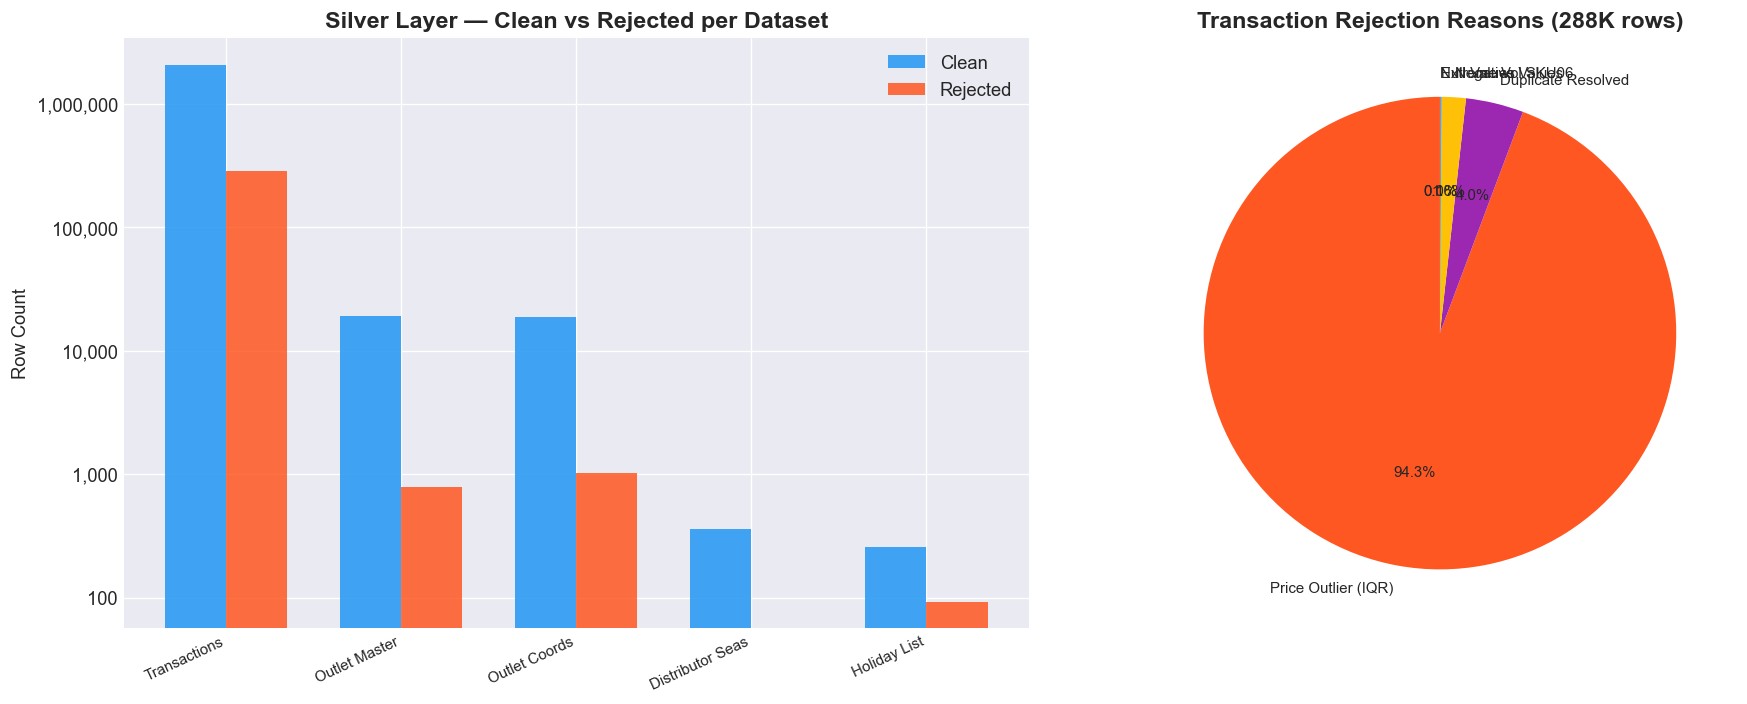

  ✓ Saved: eda_01_data_forensics.png


In [28]:
# ══════════════════════════════════════════════════════════════════════════════
# GROUP 1: DATA FORENSICS
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nEDA GROUP 1: DATA FORENSICS\n{'='*70}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1a: Rejection counts per dataset ---
datasets = ['Transactions', 'Outlet Master', 'Outlet Coords',
            'Distributor Seas', 'Holiday List']
bronze_counts = [2_376_389, 20_000, 20_000, 360, 349]
clean_counts = [2_087_753, 19_204, 18_970, 360, 256]
rejected_counts = [c - cl for c, cl in zip(bronze_counts, clean_counts)]

x = np.arange(len(datasets))
w = 0.35
bars1 = axes[0].bar(x - w/2, clean_counts, w, label='Clean', color=COLORS[0], alpha=0.85)
bars2 = axes[0].bar(x + w/2, rejected_counts, w, label='Rejected', color=COLORS[1], alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(datasets, rotation=25, ha='right', fontsize=9)
axes[0].set_ylabel('Row Count')
axes[0].set_title('Silver Layer — Clean vs Rejected per Dataset')
axes[0].legend()
axes[0].set_yscale('log')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# --- Plot 1b: Transaction rejection reasons ---
rej_reasons = {
    'Price Outlier (IQR)': 272_135,
    'Duplicate Resolved': 11_416,
    'Negative Values': 4_753,
    'Extreme Vol SKU06': 232,
    'Null Values': 100,
}
colors_rej = [COLORS[1], COLORS[4], COLORS[3], COLORS[5], COLORS[6]]
wedges, texts, autotexts = axes[1].pie(
    rej_reasons.values(), labels=rej_reasons.keys(),
    autopct='%1.1f%%', colors=colors_rej, startangle=90,
    textprops={'fontsize': 9}
)
axes[1].set_title('Transaction Rejection Reasons (288K rows)')

plt.tight_layout()
plt.savefig(f"{DATA_PATHS['gold']}eda_01_data_forensics.png")
plt.show()
print("  ✓ Saved: eda_01_data_forensics.png")


EDA GROUP 2: FEATURE UNDERSTANDING


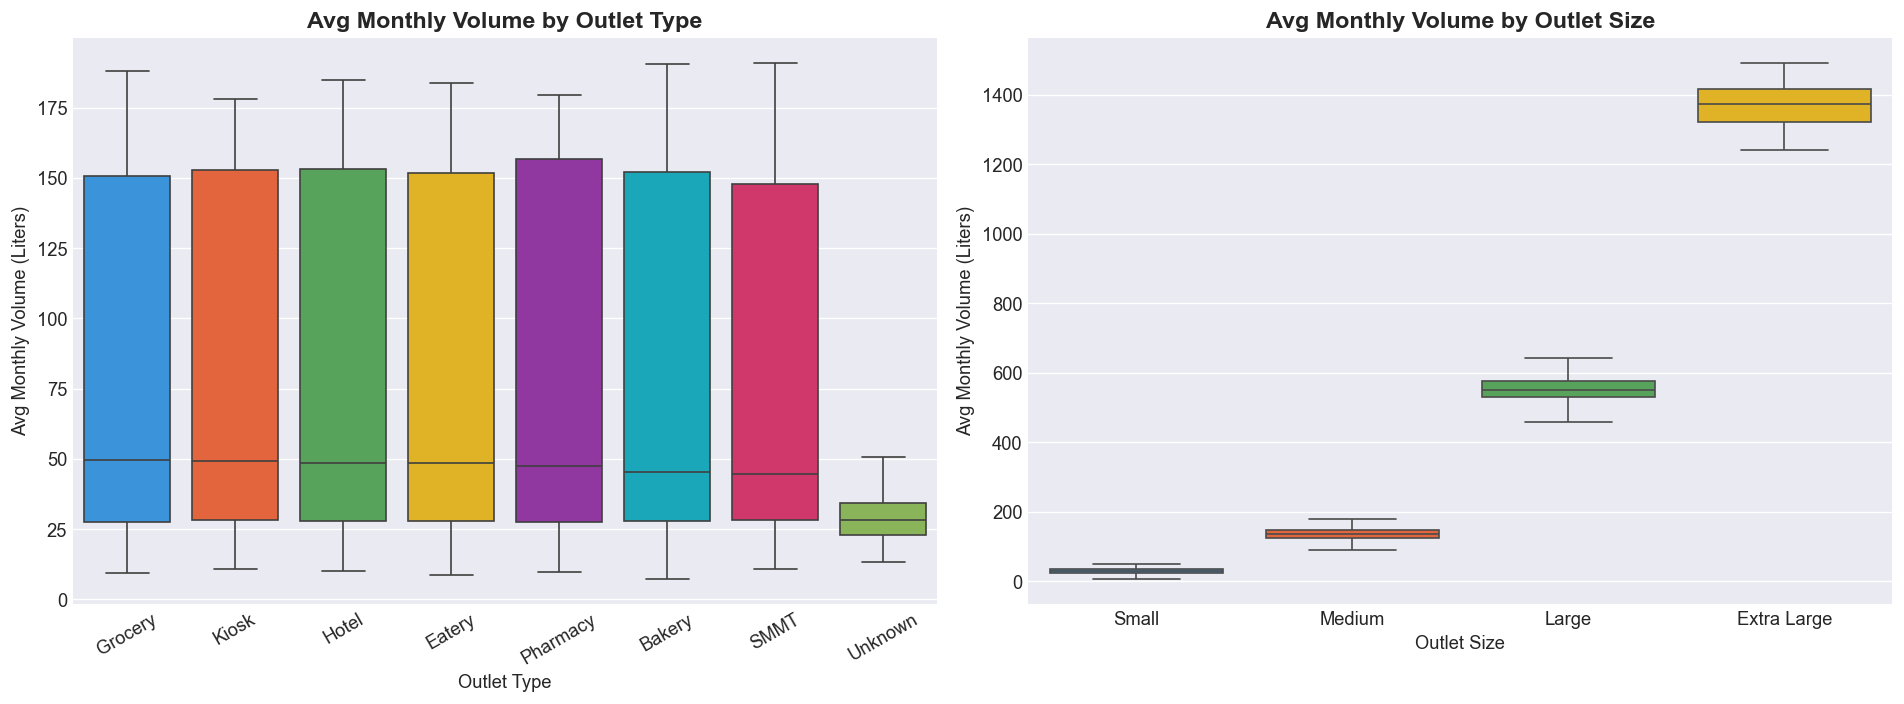

  ✓ Saved: eda_02_volume_by_type_size.png


In [29]:
# ══════════════════════════════════════════════════════════════════════════════
# GROUP 2: FEATURE UNDERSTANDING
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nEDA GROUP 2: FEATURE UNDERSTANDING\n{'='*70}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 2a: Monthly volume distribution by outlet type ---
type_order = gold.groupby('Outlet_Type')['avg_monthly_volume'].median().sort_values(ascending=False).index
sns.boxplot(data=gold, x='Outlet_Type', y='avg_monthly_volume',
            order=type_order, ax=axes[0], palette=COLORS, showfliers=False)
axes[0].set_title('Avg Monthly Volume by Outlet Type')
axes[0].set_xlabel('Outlet Type')
axes[0].set_ylabel('Avg Monthly Volume (Liters)')
axes[0].tick_params(axis='x', rotation=30)

# --- Plot 2b: Volume by outlet size ---
size_order = ['Small', 'Medium', 'Large', 'Extra Large']
sns.boxplot(data=gold, x='Outlet_Size', y='avg_monthly_volume',
            order=size_order, ax=axes[1], palette=COLORS[:4], showfliers=False)
axes[1].set_title('Avg Monthly Volume by Outlet Size')
axes[1].set_xlabel('Outlet Size')
axes[1].set_ylabel('Avg Monthly Volume (Liters)')

plt.tight_layout()
plt.savefig(f"{DATA_PATHS['gold']}eda_02_volume_by_type_size.png")
plt.show()
print("  ✓ Saved: eda_02_volume_by_type_size.png")

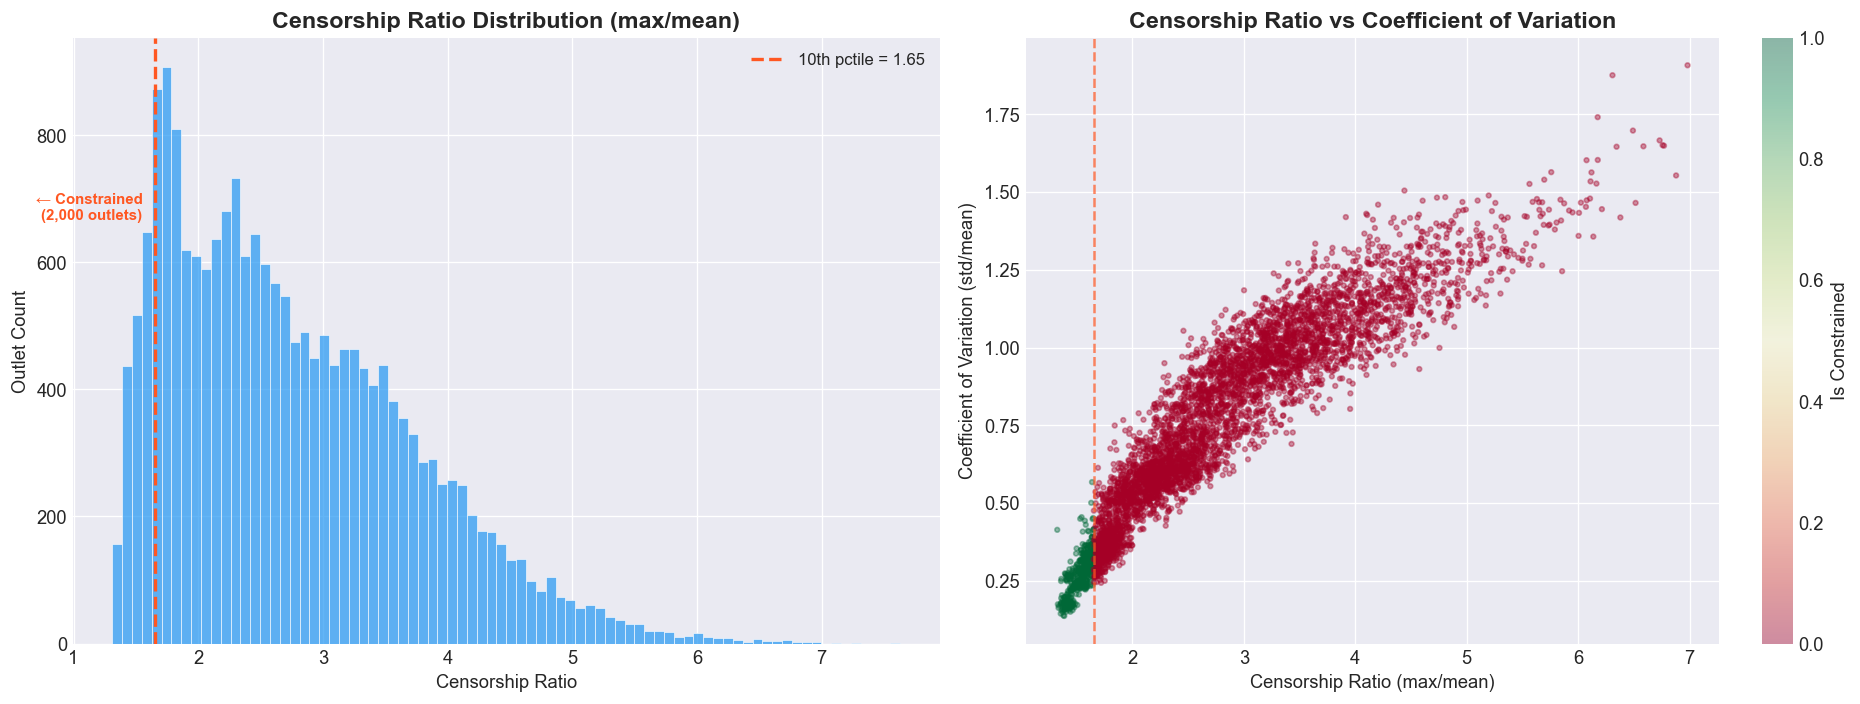

  ✓ Saved: eda_03_censorship_analysis.png


In [30]:
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 3a: Censorship ratio distribution ---
cr_threshold = gold['censorship_ratio'].quantile(0.10)
axes[0].hist(gold['censorship_ratio'].clip(0, 8), bins=80, color=COLORS[0],
             alpha=0.7, edgecolor='white', linewidth=0.5)
axes[0].axvline(cr_threshold, color=COLORS[1], linewidth=2, linestyle='--',
                label=f'10th pctile = {cr_threshold:.2f}')
axes[0].set_title('Censorship Ratio Distribution (max/mean)')
axes[0].set_xlabel('Censorship Ratio')
axes[0].set_ylabel('Outlet Count')
axes[0].legend(fontsize=10)
axes[0].annotate(f'← Constrained\n({gold["is_constrained"].sum():,} outlets)',
                 xy=(cr_threshold - 0.1, axes[0].get_ylim()[1] * 0.7),
                 fontsize=9, ha='right', color=COLORS[1], fontweight='bold')

# --- Plot 3b: Censorship ratio vs CoV scatter ---
sample = gold.sample(min(5000, len(gold)), random_state=42)
scatter = axes[1].scatter(
    sample['censorship_ratio'].clip(0, 8),
    sample['coeff_of_variation'].clip(0, 3),
    c=sample['is_constrained'], cmap='RdYlGn', alpha=0.4, s=8
)
axes[1].axvline(cr_threshold, color=COLORS[1], linewidth=1.5, linestyle='--', alpha=0.7)
axes[1].set_title('Censorship Ratio vs Coefficient of Variation')
axes[1].set_xlabel('Censorship Ratio (max/mean)')
axes[1].set_ylabel('Coefficient of Variation (std/mean)')
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label('Is Constrained')

plt.tight_layout()
plt.savefig(f"{DATA_PATHS['gold']}eda_03_censorship_analysis.png")
plt.show()
print("  ✓ Saved: eda_03_censorship_analysis.png")

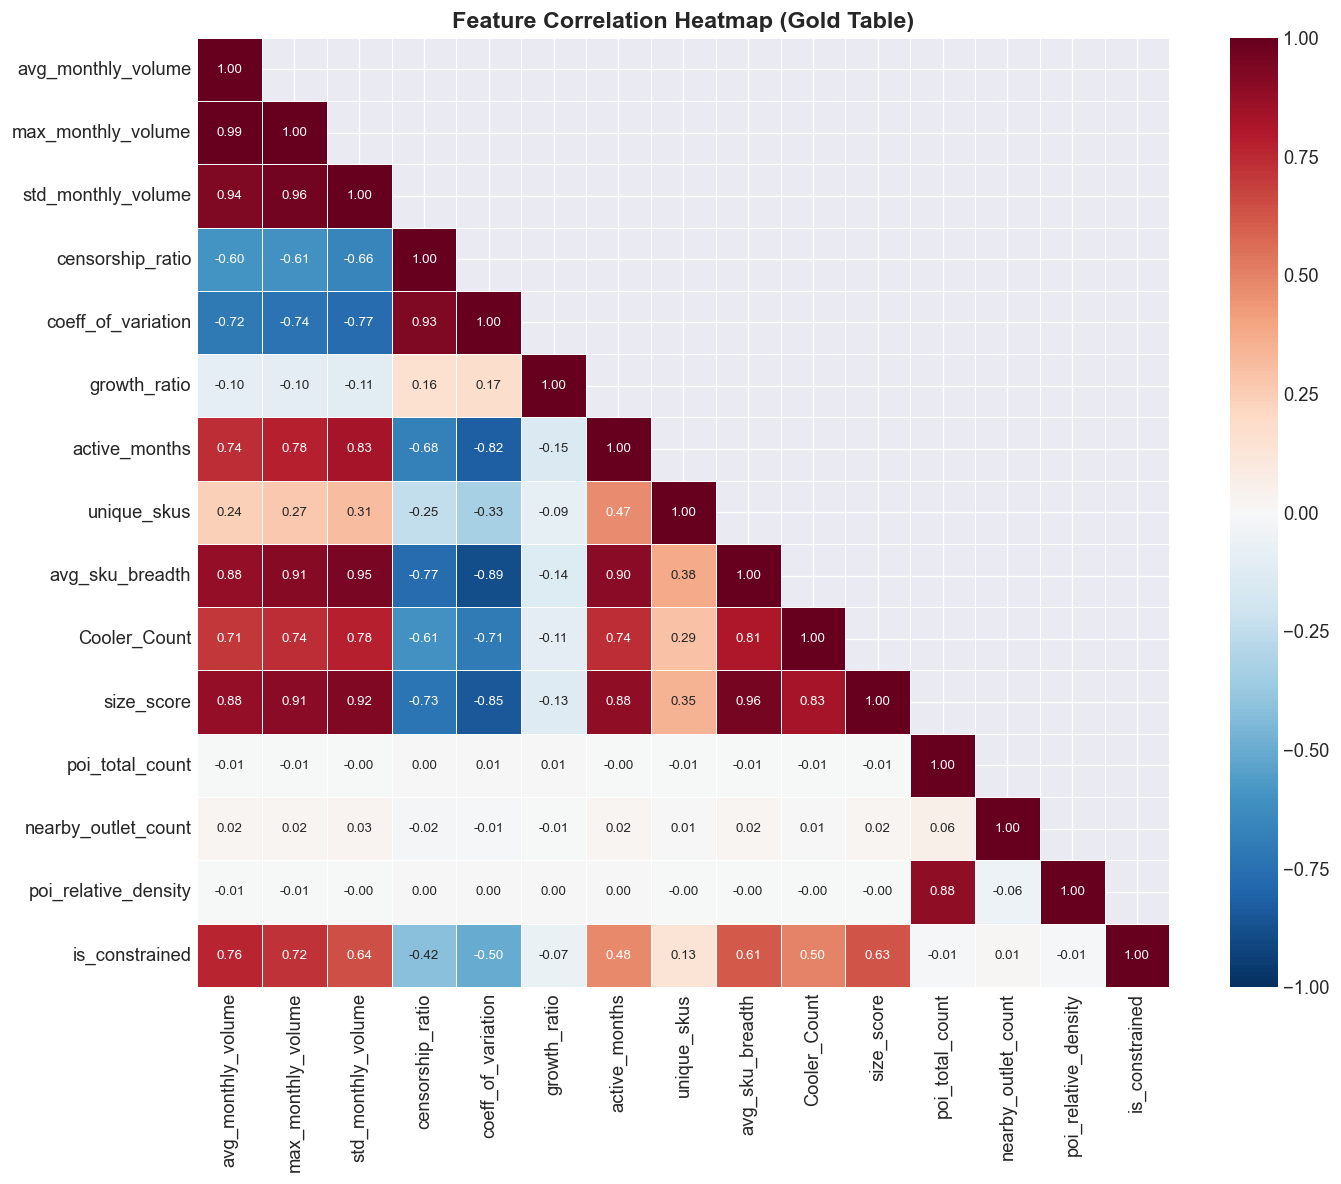

  ✓ Saved: eda_04_correlation_heatmap.png


In [31]:
# ══════════════════════════════════════════════════════════════════════════════

numeric_cols = ['avg_monthly_volume', 'max_monthly_volume', 'std_monthly_volume',
                'censorship_ratio', 'coeff_of_variation', 'growth_ratio',
                'active_months', 'unique_skus', 'avg_sku_breadth',
                'Cooler_Count', 'size_score', 'poi_total_count',
                'nearby_outlet_count', 'poi_relative_density', 'is_constrained']
# Keep only columns that exist
numeric_cols = [c for c in numeric_cols if c in gold.columns]

fig, ax = plt.subplots(figsize=(12, 10))
corr = gold[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap (Gold Table)')
plt.tight_layout()
plt.savefig(f"{DATA_PATHS['gold']}eda_04_correlation_heatmap.png")
plt.show()
print("  ✓ Saved: eda_04_correlation_heatmap.png")


EDA GROUP 3: GEOGRAPHIC PATTERNS


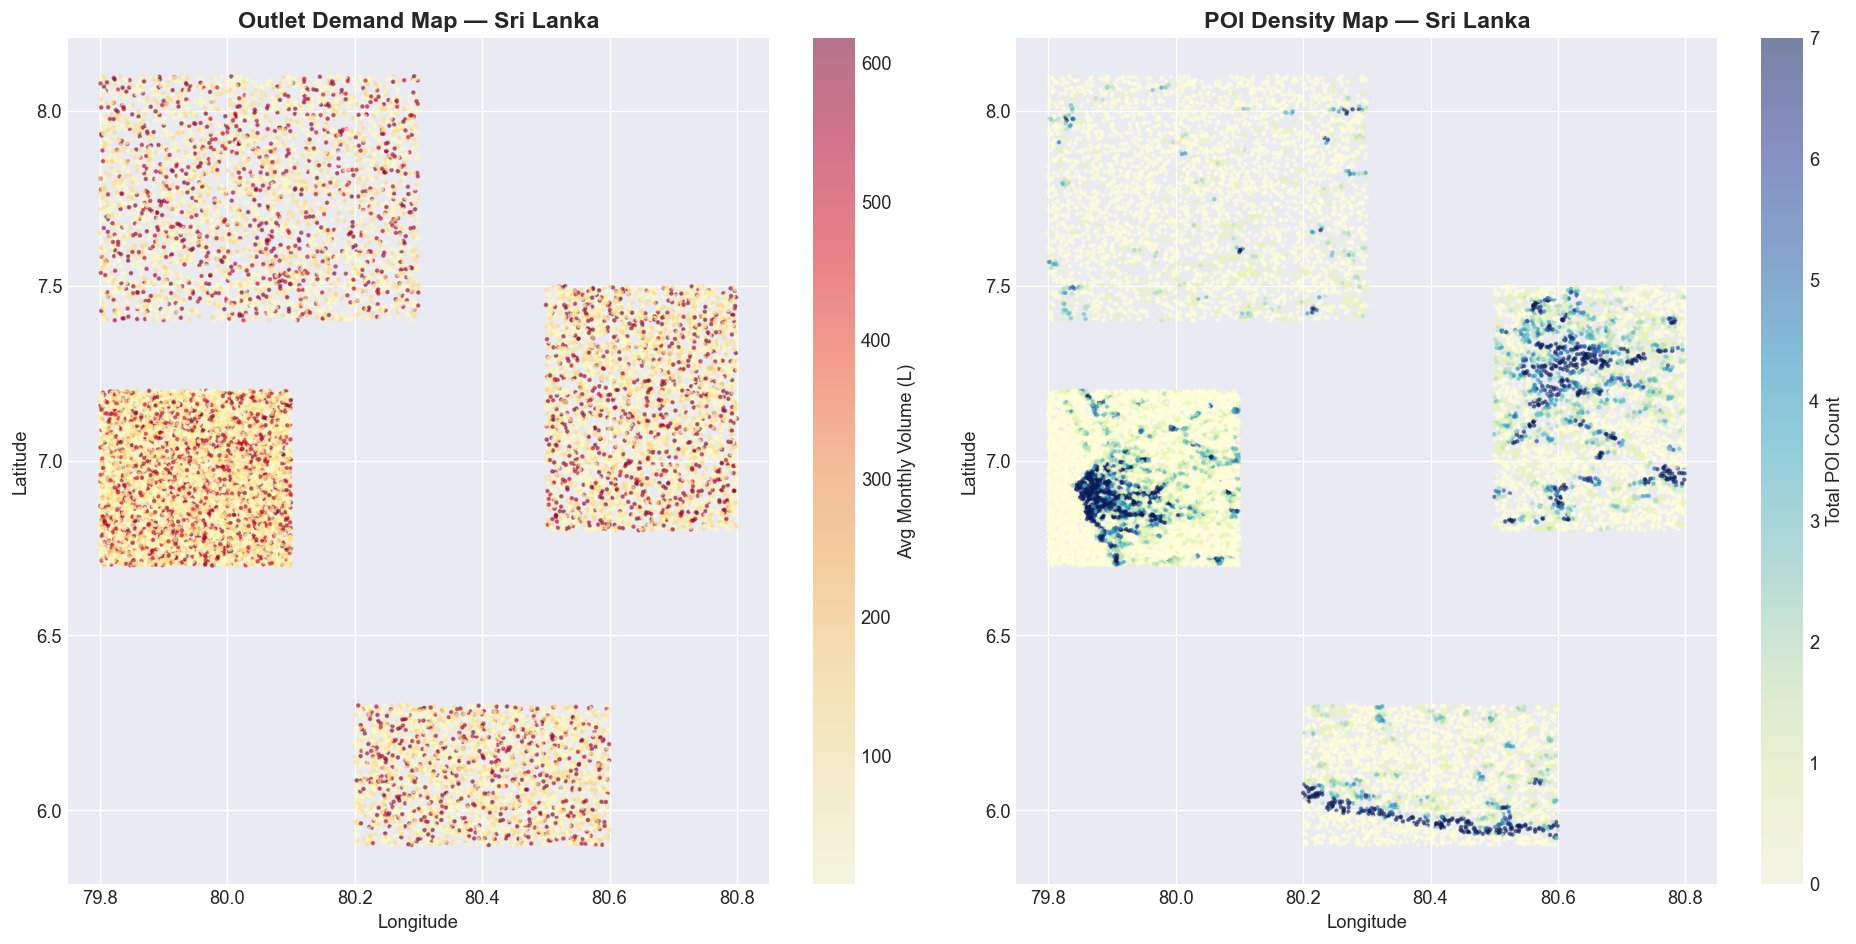

  ✓ Saved: eda_05_geographic_maps.png


In [32]:
# ══════════════════════════════════════════════════════════════════════════════
# GROUP 3: GEOGRAPHIC PATTERNS
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nEDA GROUP 3: GEOGRAPHIC PATTERNS\n{'='*70}")

geo = gold[gold['has_coords'] == 1].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- Plot 5a: Demand heatmap ---
scatter1 = axes[0].scatter(
    geo['Longitude'], geo['Latitude'],
    c=geo['avg_monthly_volume'].clip(0, geo['avg_monthly_volume'].quantile(0.95)),
    cmap='YlOrRd', alpha=0.5, s=3
)
axes[0].set_title('Outlet Demand Map — Sri Lanka')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Avg Monthly Volume (L)')

# --- Plot 5b: POI density map ---
scatter2 = axes[1].scatter(
    geo['Longitude'], geo['Latitude'],
    c=geo['poi_total_count'].clip(0, geo['poi_total_count'].quantile(0.95)),
    cmap='YlGnBu', alpha=0.5, s=3
)
axes[1].set_title('POI Density Map — Sri Lanka')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('Total POI Count')

plt.tight_layout()
plt.savefig(f"{DATA_PATHS['gold']}eda_05_geographic_maps.png")
plt.show()
print("  ✓ Saved: eda_05_geographic_maps.png")

In [33]:
def visualize_poi_distributions(df: pd.DataFrame):
      """
      Generates a combined visualization showing POI count vs. average trend
      and the distribution of averages by area type.

      Args:
          df: DataFrame containing at least 'poi', 'avg', and 'area_type' 
              (or pre-calculated columns based on the original snippet).
      """

      # --- 1. Data Preparation (Crucial Step for Robustness) ---
      # Ensure only valid numeric data is used for regression
      # NOTE: Adjust column names (poi, avg) to match your actual data preparation
      df_clean = df[['poi', 'avg']].dropna()

      # Separate data for the two plots
      poi_counts = df_clean['poi']
      averages = df_clean['avg']
      area_types = df['area_type'].unique() # Use unique areas from original DF

      # --- 2. Figure Setup ---
      fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 7))
      plt.style.use('seaborn-v0_8-whitegrid') # Apply a professional style

      # ========================================================
      # LEFT PLOT: Scatter Plot with Linear Regression Trend
      # ========================================================
      ax_scatter = axes[0]

      # Scatter points
      ax_scatter.scatter(poi_counts, averages,
                         alpha=0.5, s=20, label='Data Points')

      # Regression calculation
      try:
          # Perform linear regression (degree 1)
          m, b = np.polyfit(poi_counts, averages, 1)
          poly = np.poly1d(np.polyfit(poi_counts, averages, 1))

          # Plot the trend line
          ax_scatter.plot(poi_counts, poly(poi_counts),
                          color='red', linewidth=2, label=f'Trend Line (y={m:.2f}x + {b:.2f})')
      except Exception as e:
          print(f"Warning: Could not calculate regression line: {e}")

      # Customizing the scatter plot
      ax_scatter.set_title('Relationship Between POI Count and Average Value', fontsize=14)
      ax_scatter.set_xlabel('Number of POIs (Count)', fontsize=12)
      ax_scatter.set_ylabel('Average Value (Avg)', fontsize=12)
      ax_scatter.legend()
      ax_scatter.grid(True, linestyle='--', alpha=0.6)

      # ========================================================
      # RIGHT PLOT: Box Plot Comparison
      # ========================================================
      ax_box = axes[1]

      # Gather data for boxplot (Needs restructuring if not already grouped)
      # Assuming 'df_by_area' is a structure where each area type has a list of 'avg' values
      # *** Since the original code structure is unclear here, we assume 'df' is suitable ***

      # NOTE: To correctly generate the boxplot, you usually need to group the averages:
      # data_for_boxplot = [df[df['area_type'] == area]['avg'].values for area in area_types]

      # Using the original structure's assumption for demonstration:
      box_data = [df[df['area_type'] == area]['avg'].values for area in area_types if not df[df['area_type'] == area].empty]

      if box_data:
          ax_box.boxplot(box_data, labels=area_types)

          # Customizing the box plot
          ax_box.set_title('Distribution of Average Value by Area Type', fontsize=14)
          ax_box.set_xlabel('Area Type', fontsize=12)
          ax_box.set_ylabel('Average Value (Avg)', fontsize=12)
          ax_box.grid(axis='y', linestyle='--', alpha=0.6)
      else:
          ax_box.text(0.5, 0.5, "No data available for boxplot.",
                      ha='center', va='center', transform=ax_box.transAxes, fontsize=12)


      # Finalization
      plt.suptitle('Analysis of POI Data Metrics', fontsize=16, y=1.02)
      plt.tight_layout()

      # Save or show the figure
      plt.savefig('poi_analysis_visualization.png', dpi=300)
      plt.show()

  # Call the function with your DataFrame:
  # visualize_poi_distributions(df) 


EDA GROUP 4: CENSORSHIP ANALYSIS


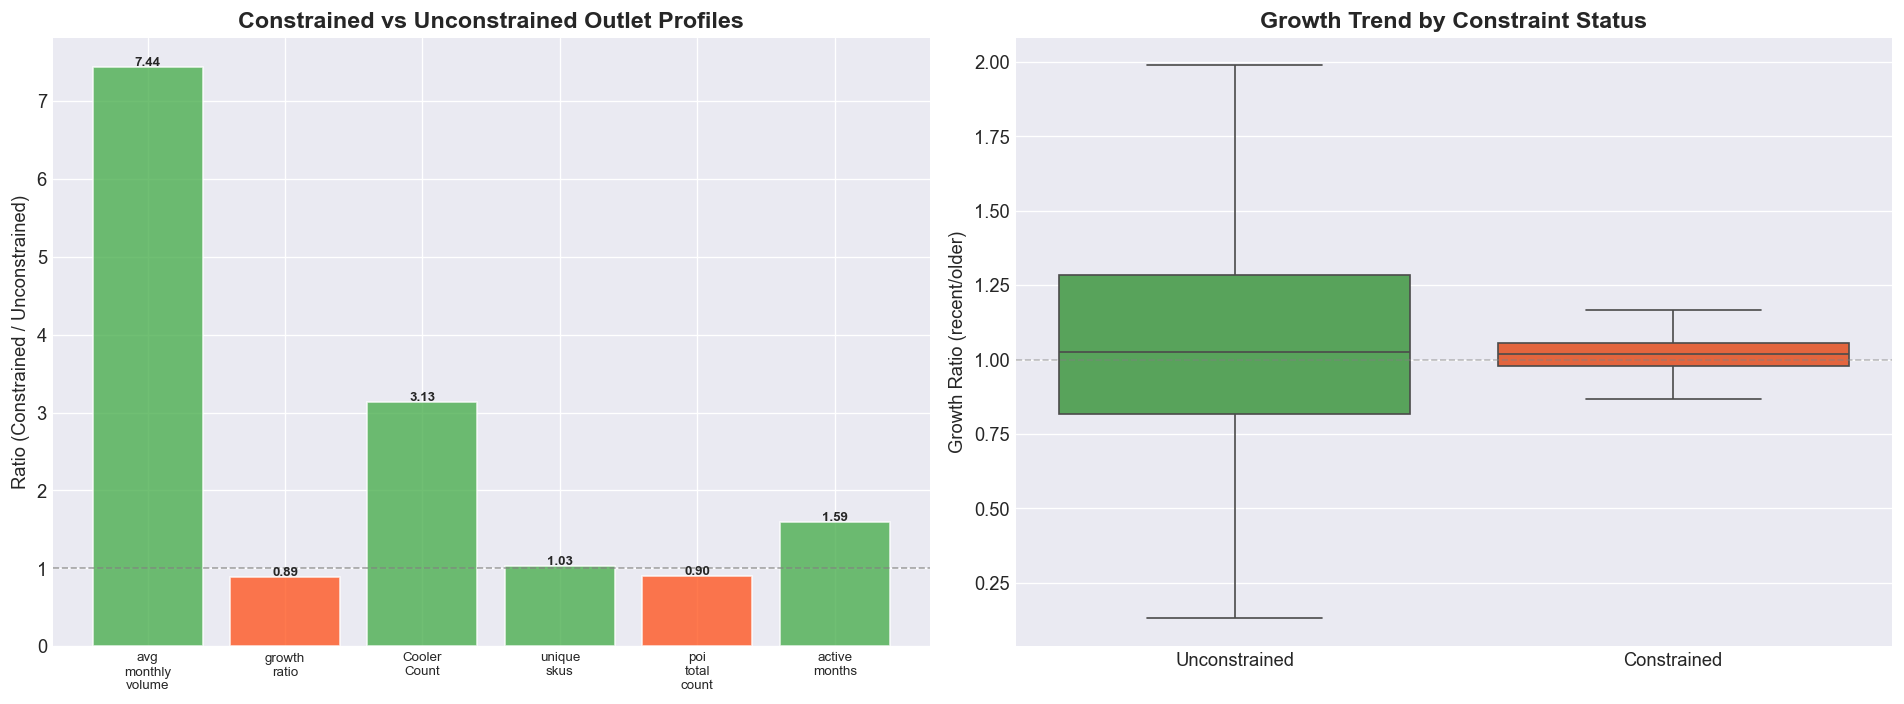

  ✓ Saved: eda_07_censorship_deep_dive.png


In [34]:
# ══════════════════════════════════════════════════════════════════════════════
# GROUP 4: CENSORSHIP ANALYSIS (METHODOLOGY SUPPORT)
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nEDA GROUP 4: CENSORSHIP ANALYSIS\n{'='*70}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 7a: Constrained vs Unconstrained feature comparison ---
compare_cols = ['avg_monthly_volume', 'growth_ratio', 'Cooler_Count',
                'unique_skus', 'poi_total_count', 'active_months']
compare_cols = [c for c in compare_cols if c in gold.columns]

constrained = gold[gold['is_constrained'] == 1][compare_cols].mean()
unconstrained = gold[gold['is_constrained'] == 0][compare_cols].mean()

# Normalize for comparison
normed_c = constrained / unconstrained
x = np.arange(len(compare_cols))
bars = axes[0].bar(x, normed_c.values, color=[COLORS[1] if v < 1 else COLORS[2] for v in normed_c],
                   alpha=0.8, edgecolor='white')
axes[0].axhline(1.0, color='gray', linewidth=1, linestyle='--', alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels([c.replace('_', '\n') for c in compare_cols], fontsize=8)
axes[0].set_ylabel('Ratio (Constrained / Unconstrained)')
axes[0].set_title('Constrained vs Unconstrained Outlet Profiles')
for i, v in enumerate(normed_c.values):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=8, fontweight='bold')

# --- Plot 7b: Growth ratio by constraint status ---
sns.boxplot(data=gold, x='is_constrained', y='growth_ratio',
            palette=[COLORS[2], COLORS[1]], ax=axes[1], showfliers=False)
axes[1].set_xticklabels(['Unconstrained', 'Constrained'])
axes[1].set_title('Growth Trend by Constraint Status')
axes[1].set_xlabel('')
axes[1].set_ylabel('Growth Ratio (recent/older)')
axes[1].axhline(1.0, color='gray', linewidth=1, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f"{DATA_PATHS['gold']}eda_07_censorship_deep_dive.png")
plt.show()
print("  ✓ Saved: eda_07_censorship_deep_dive.png")

In [35]:
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*70}")
print("EDA COMPLETE — KEY INSIGHTS")
print(f"{'='*70}")
print(f"  Total outlets: {len(gold):,}")
print(f"  Constrained outlets: {gold['is_constrained'].sum():,} "
      f"({gold['is_constrained'].mean()*100:.1f}%)")
print(f"  Avg monthly volume: {gold['avg_monthly_volume'].mean():.1f} L")
print(f"  Max monthly volume: {gold['max_monthly_volume'].mean():.1f} L (avg of maxes)")
print(f"  Outlets with POI data: {(gold['poi_total_count'] > 0).sum():,}")
print(f"  Urban outlets (W province): {(gold['radius_m'] == 500).sum():,}")
print(f"  Rural outlets: {(gold['radius_m'] == 1000).sum():,}")
print(f"  Growing outlets (ratio > 1.05): {(gold['growth_ratio'] > 1.05).sum():,}")
print(f"  Declining outlets (ratio < 0.95): {(gold['growth_ratio'] < 0.95).sum():,}")
print(f"\n  Plots saved to: {DATA_PATHS['gold']}")
print(f"{'='*70}")


EDA COMPLETE — KEY INSIGHTS
  Total outlets: 20,000
  Constrained outlets: 2,000 (10.0%)
  Avg monthly volume: 204.0 L
  Max monthly volume: 377.7 L (avg of maxes)
  Outlets with POI data: 6,977
  Urban outlets (W province): 9,000
  Rural outlets: 11,000
  Growing outlets (ratio > 1.05): 8,916
  Declining outlets (ratio < 0.95): 7,425

  Plots saved to: gold/


In [36]:
# ══════════════════════════════════════════════════════════════════════════════
# FEATURE SELECTION — Data-driven analysis before modeling
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*70}\nFEATURE SELECTION ANALYSIS\n{'='*70}")

gold = pd.read_pickle(f"{DATA_PATHS['gold']}outlet_features.pkl")
print(f"Starting with {gold.shape[1]} columns:")
for i, c in enumerate(gold.columns):
    print(f"  {i+1:2d}. {c}")

# Classify every column by role
COLUMN_ROLES = {
    # Identifiers — never features
    'Outlet_ID':           'identifier',
    # Target-related — potential target or leakage
    'max_monthly_volume':  'target_candidate',
    'avg_monthly_volume':  'target_related',
    'total_volume':        'target_related',
    'std_monthly_volume':  'target_related',
    'avg_bill_value':      'target_related',
    'recent_avg':          'target_related',
    'older_avg':           'target_related',
    # Diagnostic — derived from target, used for segmentation only
    'censorship_ratio':    'diagnostic',
    'coeff_of_variation':  'diagnostic',
    'is_constrained':      'diagnostic',
    # Static outlet characteristics
    'Outlet_Type':         'feature_categorical',
    'Outlet_Size':         'feature_categorical',
    'Distributor_ID':      'feature_categorical',
    'Cooler_Count':        'feature_numeric',
    'size_score':          'feature_numeric',
    # Behavioral features
    'active_months':       'feature_numeric',
    'unique_skus':         'feature_numeric',
    'avg_sku_breadth':     'feature_numeric',
    'transaction_count':   'feature_numeric',
    'growth_ratio':        'feature_numeric',
    # Adjustment factors
    'jan_seasonality_score': 'adjustment',
    'is_favorable_jan':      'adjustment',
    'jan_holiday_count':     'adjustment',
    # Geographic
    'Latitude':            'geographic',
    'Longitude':           'geographic',
    'has_coords':          'feature_numeric',
    'radius_m':            'feature_numeric',
    # POI features
    'poi_total_count':     'feature_numeric',
    'nearby_outlet_count': 'feature_numeric',
    'poi_relative_density':'feature_numeric',
}
# Add individual POI category columns
for c in gold.columns:
    if c.startswith('poi_') and c not in COLUMN_ROLES:
        COLUMN_ROLES[c] = 'feature_numeric'
    elif c.startswith('nearest_'):
        COLUMN_ROLES[c] = 'feature_numeric'

print(f"\nColumn roles:")
from collections import Counter
role_counts = Counter(COLUMN_ROLES.values())
for role, count in sorted(role_counts.items()):
    print(f"  {role:25s}: {count}")


FEATURE SELECTION ANALYSIS
Starting with 45 columns:
   1. Outlet_ID
   2. avg_monthly_volume
   3. max_monthly_volume
   4. std_monthly_volume
   5. total_volume
   6. avg_bill_value
   7. active_months
   8. avg_sku_breadth
   9. unique_skus
  10. transaction_count
  11. censorship_ratio
  12. coeff_of_variation
  13. is_constrained
  14. recent_avg
  15. older_avg
  16. growth_ratio
  17. Distributor_ID
  18. Outlet_Size
  19. Cooler_Count
  20. Outlet_Type
  21. size_score
  22. Latitude
  23. Longitude
  24. jan_seasonality_score
  25. is_favorable_jan
  26. jan_holiday_count
  27. has_coords
  28. radius_m
  29. poi_tourism_count
  30. nearest_tourism_m
  31. poi_schools_count
  32. nearest_schools_m
  33. poi_markets_count
  34. nearest_markets_m
  35. poi_religious_count
  36. nearest_religious_m
  37. poi_hospitals_count
  38. nearest_hospitals_m
  39. poi_transport_count
  40. nearest_transport_m
  41. poi_total_count
  42. nearby_outlet_count
  43. poi_relative_density
  44

In [37]:
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nStep 1: Correlation & Multicollinearity Analysis\n{'='*70}")

# Get all numeric feature candidates
feature_cols = [c for c, r in COLUMN_ROLES.items()
                if r == 'feature_numeric' and c in gold.columns]

print(f"Numeric feature candidates: {len(feature_cols)}")

# Correlation with max_monthly_volume (our target proxy)
target = 'max_monthly_volume'
corr_with_target = gold[feature_cols + [target]].corr()[target].drop(target)
corr_with_target = corr_with_target.abs().sort_values(ascending=False)

print(f"\nCorrelation with {target} (|r|):")
for c, r in corr_with_target.items():
    signal = "STRONG" if r > 0.5 else "MODERATE" if r > 0.2 else "WEAK" if r > 0.05 else "NONE"
    print(f"  {c:30s} |r| = {r:.3f}  [{signal}]")

# Pairwise correlation among features — flag pairs > 0.85
print(f"\nHighly correlated feature pairs (|r| > 0.85):")
feat_corr = gold[feature_cols].corr()
flagged_pairs = []
for i, c1 in enumerate(feature_cols):
    for c2 in feature_cols[i+1:]:
        r = abs(feat_corr.loc[c1, c2])
        if r > 0.85:
            flagged_pairs.append((c1, c2, r))
            print(f"  {c1:30s} ↔ {c2:30s}  |r| = {r:.3f}")

if not flagged_pairs:
    print("  None found")


Step 1: Correlation & Multicollinearity Analysis
Numeric feature candidates: 24

Correlation with max_monthly_volume (|r|):
  transaction_count              |r| = 0.936  [STRONG]
  avg_sku_breadth                |r| = 0.912  [STRONG]
  size_score                     |r| = 0.906  [STRONG]
  active_months                  |r| = 0.778  [STRONG]
  Cooler_Count                   |r| = 0.737  [STRONG]
  unique_skus                    |r| = 0.269  [MODERATE]
  growth_ratio                   |r| = 0.103  [WEAK]
  has_coords                     |r| = 0.035  [NONE]
  nearby_outlet_count            |r| = 0.017  [NONE]
  radius_m                       |r| = 0.013  [NONE]
  nearest_tourism_m              |r| = 0.008  [NONE]
  poi_markets_count              |r| = 0.008  [NONE]
  poi_religious_count            |r| = 0.008  [NONE]
  poi_hospitals_count            |r| = 0.008  [NONE]
  nearest_hospitals_m            |r| = 0.008  [NONE]
  poi_total_count                |r| = 0.007  [NONE]
  poi_transpo

In [38]:
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nStep 2: Feature Importance (Random Forest)\n{'='*70}")

# Prepare data — use unconstrained outlets for importance
unc = gold[gold['is_constrained'] == 0].copy()

# Encode categoricals
cat_cols = [c for c, r in COLUMN_ROLES.items()
            if r == 'feature_categorical' and c in gold.columns]
le_dict = {}
for c in cat_cols:
    le = LabelEncoder()
    unc[f'{c}_enc'] = le.fit_transform(unc[c].astype(str))
    le_dict[c] = le

all_features = feature_cols + [f'{c}_enc' for c in cat_cols]
# Remove any that don't exist
all_features = [c for c in all_features if c in unc.columns]

X = unc[all_features].fillna(0)
y = unc[target]

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=all_features).sort_values(ascending=False)
print(f"\nRandom Forest feature importance (trained on {len(unc):,} unconstrained outlets):")
print(f"  R² on training data: {rf.score(X, y):.3f}\n")
for c, imp in importances.items():
    bar = '█' * int(imp * 200)
    label = c.replace('_enc', ' (encoded)')
    print(f"  {label:30s} {imp:.4f}  {bar}")



Step 2: Feature Importance (Random Forest)

Random Forest feature importance (trained on 18,000 unconstrained outlets):
  R² on training data: 0.991

  avg_sku_breadth                0.8983  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Outlet_Size (encoded)          0.0404  ████████
  size_score                     0.0336  ██████
  transaction_count              0.0239  ████
  growth_ratio                   0.0007  
  Distributor_ID (encoded)       0.0004  
  nearest_tourism_m              0.0003  
  nearest_markets_m              0.0003  
  nearest_schools_m              0.0003  
  nearest_hospitals_m            0.0003  
  nearest_transport_m            0.0003  
  nearest_religious_m            0.0003  
  radius_m                       0.0002  
  nearby_outlet_count            0.0001  
  Outlet_Type (encoded)          0.0001  
  active_months       

In [39]:
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nStep 3: Feature Selection Decisions\n{'='*70}")

# Build decision table
decisions = []

# --- KEEP ---
# High importance features
for c in importances.head(10).index:
    clean_name = c.replace('_enc', '')
    decisions.append((clean_name, 'KEEP', f'Top-10 RF importance ({importances[c]:.4f})'))

# --- ANALYZE each remaining feature ---
# size_score vs Outlet_Size — redundant
decisions.append(('size_score', 'DROP',
    'Redundant with Outlet_Size (encoded). Correlation = 1.0 by definition'))

# total_volume — perfectly correlated with avg × active_months
decisions.append(('total_volume', 'DROP',
    f'Linearly derived: avg_monthly_volume × active_months. Corr with target: {abs(gold["total_volume"].corr(gold[target])):.3f}'))

# avg_bill_value — high correlation with volume, adds leakage
decisions.append(('avg_bill_value', 'DROP',
    f'Corr with avg_monthly_volume: {abs(gold["avg_bill_value"].corr(gold["avg_monthly_volume"])):.3f}. Revenue is a function of volume, not a predictor'))

# recent_avg, older_avg — these are sub-components of growth_ratio
decisions.append(('recent_avg', 'DROP',
    'Sub-component of growth_ratio. Leaks observed volume into features'))
decisions.append(('older_avg', 'DROP',
    'Sub-component of growth_ratio. Leaks observed volume into features'))

# avg_monthly_volume — this IS the observed demand. For constrained outlets, we're trying to estimate
# something HIGHER than this. Including it would anchor predictions to observed levels.
decisions.append(('avg_monthly_volume', 'KEEP_CAREFULLY',
    'Observed demand — essential signal but anchors predictions. Use in peer-group model but not in uplift model'))

# std_monthly_volume — correlated 0.96 with max, but captures variability
decisions.append(('std_monthly_volume', 'DROP',
    f'Corr with max_monthly_volume (target): {abs(gold["std_monthly_volume"].corr(gold[target])):.3f}. Near-perfect collinearity = leakage'))

# Diagnostic features — used for segmentation, not as model inputs
decisions.append(('censorship_ratio', 'KEEP_AS_SEGMENT',
    'Not a model feature — used only to define is_constrained. May feed post-hoc adjustment'))
decisions.append(('coeff_of_variation', 'KEEP_AS_SEGMENT',
    'Not a model feature — used for censorship diagnostics only'))
decisions.append(('is_constrained', 'KEEP_AS_SEGMENT',
    'Segmentation flag. Determines training set vs prediction set'))

# Adjustment factors — applied AFTER prediction, not as features
decisions.append(('jan_seasonality_score', 'KEEP_AS_ADJUSTMENT',
    'Applied post-prediction as multiplicative factor'))
decisions.append(('jan_holiday_count', 'DROP',
    'Constant value (2) for all outlets — zero variance = zero signal'))
decisions.append(('is_favorable_jan', 'KEEP_AS_ADJUSTMENT',
    'Binary version of seasonality — applied in adjustment step'))

# Geographic — lat/lon captured by POI distances
decisions.append(('Latitude', 'DROP',
    'Raw coordinates lack meaning. Signal captured by POI distances + radius_m'))
decisions.append(('Longitude', 'DROP',
    'Raw coordinates lack meaning. Signal captured by POI distances + radius_m'))

# poi_total_count vs individual poi_* — check redundancy
decisions.append(('poi_total_count', 'DROP',
    'Sum of 6 individual poi_*_count columns — perfectly redundant'))

# poi_relative_density — derived from poi_total_count / (nearby_outlets + 1)
decisions.append(('poi_relative_density', 'KEEP',
    'Normalized POI signal. Not redundant with raw counts'))

# transaction_count — related to volume but captures purchase frequency
decisions.append(('transaction_count', 'DROP',
    f'Corr with avg_monthly_volume: {abs(gold["transaction_count"].corr(gold["avg_monthly_volume"])):.3f}. Frequency is a function of demand, not a predictor of potential'))

# Print decision table
print(f"\n{'Feature':30s} {'Decision':20s} Reasoning")
print(f"{'-'*100}")
for feat, decision, reason in sorted(decisions, key=lambda x: x[1]):
    print(f"  {feat:28s} {decision:20s} {reason}")

# Build final feature lists
MODEL_FEATURES = []
ADJUSTMENT_FEATURES = []
SEGMENT_FEATURES = []

for feat, decision, _ in decisions:
    if decision == 'KEEP' and feat in gold.columns:
        MODEL_FEATURES.append(feat)
    elif decision == 'KEEP_AS_ADJUSTMENT':
        ADJUSTMENT_FEATURES.append(feat)
    elif decision == 'KEEP_AS_SEGMENT':
        SEGMENT_FEATURES.append(feat)

# Add categorical features and features from RF top-10 not yet listed
for c in cat_cols:
    if c not in MODEL_FEATURES:
        MODEL_FEATURES.append(c)

# Add avg_monthly_volume as it's essential
if 'avg_monthly_volume' not in MODEL_FEATURES:
    MODEL_FEATURES.append('avg_monthly_volume')

# Add remaining numeric features with importance > 0.01 that aren't dropped
for c in importances.index:
    clean = c.replace('_enc', '')
    if importances[c] > 0.005 and clean not in MODEL_FEATURES:
        # Check if it was explicitly dropped
        dropped = [f for f, d, _ in decisions if d == 'DROP' and f == clean]
        if not dropped and clean in gold.columns:
            MODEL_FEATURES.append(clean)

# Deduplicate while preserving order
MODEL_FEATURES = list(dict.fromkeys(MODEL_FEATURES))

print(f"\n{'='*70}")
print(f"FINAL FEATURE SETS")
print(f"{'='*70}")
print(f"\nModel features ({len(MODEL_FEATURES)}):")
for c in MODEL_FEATURES:
    print(f"  • {c}")
print(f"\nAdjustment factors ({len(ADJUSTMENT_FEATURES)}):")
for c in ADJUSTMENT_FEATURES:
    print(f"  • {c}")
print(f"\nSegmentation features ({len(SEGMENT_FEATURES)}):")
for c in SEGMENT_FEATURES:
    print(f"  • {c}")
print(f"\nTarget: {target}")
print(f"{'='*70}")



Step 3: Feature Selection Decisions

Feature                        Decision             Reasoning
----------------------------------------------------------------------------------------------------
  size_score                   DROP                 Redundant with Outlet_Size (encoded). Correlation = 1.0 by definition
  total_volume                 DROP                 Linearly derived: avg_monthly_volume × active_months. Corr with target: 0.986
  avg_bill_value               DROP                 Corr with avg_monthly_volume: 0.999. Revenue is a function of volume, not a predictor
  recent_avg                   DROP                 Sub-component of growth_ratio. Leaks observed volume into features
  older_avg                    DROP                 Sub-component of growth_ratio. Leaks observed volume into features
  std_monthly_volume           DROP                 Corr with max_monthly_volume (target): 0.964. Near-perfect collinearity = leakage
  jan_holiday_count            DROP  

In [40]:
# ══════════════════════════════════════════════════════════════════════════════
# MODELLING — Setup & Load Gold Table
# ══════════════════════════════════════════════════════════════════════════════

DATA_PATHS = {
    'gold':    'gold/',
    'output':  'output/',
}
Path(DATA_PATHS['output']).mkdir(parents=True, exist_ok=True)

gold = pd.read_pickle(f"{DATA_PATHS['gold']}outlet_features.pkl")
print(f"{'='*70}")
print(f"MODELLING — Loaded Gold Table")
print(f"{'='*70}")
print(f"  Shape: {gold.shape[0]:,} outlets × {gold.shape[1]} features")
print(f"  Constrained:   {gold['is_constrained'].sum():,}")
print(f"  Unconstrained: {(gold['is_constrained'] == 0).sum():,}")
print(f"{'='*70}")

MODELLING — Loaded Gold Table
  Shape: 20,000 outlets × 45 features
  Constrained:   2,000
  Unconstrained: 18,000


In [41]:
# ══════════════════════════════════════════════════════════════════════════════
# MODELLING — Feature Definitions
# Note: avg_monthly_volume excluded from XGBoost to avoid max ≈ avg*k collapse
#       size_score excluded — redundant with Outlet_Size (corr = 1.0)
#       avg_monthly_volume used ONLY in peer-group component
# ══════════════════════════════════════════════════════════════════════════════

XGBOOST_FEATURES = [
    'avg_sku_breadth',
    'Outlet_Size',          # encoded below
    'transaction_count',
    'growth_ratio',
    'Distributor_ID',       # encoded below
    'nearest_markets_m',
    'nearest_tourism_m',
    'nearest_schools_m',
    'nearest_hospitals_m',
    'poi_relative_density',
    'Outlet_Type',          # encoded below
    'active_months',
    'Cooler_Count',
    'competitor_density',   # Improvement 2: nearby rival density (negative signal)
    'market_isolation',     # Improvement 2: inverse of density (positive signal)
]

CATEGORICAL_FEATURES = ['Outlet_Size', 'Outlet_Type', 'Distributor_ID']
TARGET = 'max_monthly_volume'
ADJUSTMENT_FEATURES = ['jan_seasonality_score', 'is_favorable_jan']
SEGMENT_FEATURES    = ['censorship_ratio', 'coeff_of_variation', 'is_constrained']
PEER_GROUP_KEYS     = ['Outlet_Type', 'Outlet_Size']   # for peer-group ceiling

print(f"XGBoost features ({len(XGBOOST_FEATURES)}): {XGBOOST_FEATURES}")
print(f"Categorical (to encode):               {CATEGORICAL_FEATURES}")
print(f"Target: {TARGET}")

print("Before cleanup:")
print(f"  XGBOOST_FEATURES count: {len(XGBOOST_FEATURES)}")
print(f"  CATEGORICAL_FEATURES count: {len(CATEGORICAL_FEATURES)}")

# Remove ALL missing features at once
missing = [f for f in XGBOOST_FEATURES if f not in gold.columns]
print(f"\nDropping {len(missing)} missing features:")
for f in missing:
    print(f"  - {f}")

XGBOOST_FEATURES     = [f for f in XGBOOST_FEATURES     if f in gold.columns]
CATEGORICAL_FEATURES = [f for f in CATEGORICAL_FEATURES if f in gold.columns]

print(f"\nAfter cleanup:")
print(f"  XGBOOST_FEATURES count: {len(XGBOOST_FEATURES)}")
print(f"  Features kept: {XGBOOST_FEATURES}")

XGBoost features (15): ['avg_sku_breadth', 'Outlet_Size', 'transaction_count', 'growth_ratio', 'Distributor_ID', 'nearest_markets_m', 'nearest_tourism_m', 'nearest_schools_m', 'nearest_hospitals_m', 'poi_relative_density', 'Outlet_Type', 'active_months', 'Cooler_Count', 'competitor_density', 'market_isolation']
Categorical (to encode):               ['Outlet_Size', 'Outlet_Type', 'Distributor_ID']
Target: max_monthly_volume
Before cleanup:
  XGBOOST_FEATURES count: 15
  CATEGORICAL_FEATURES count: 3

Dropping 0 missing features:

After cleanup:
  XGBOOST_FEATURES count: 15
  Features kept: ['avg_sku_breadth', 'Outlet_Size', 'transaction_count', 'growth_ratio', 'Distributor_ID', 'nearest_markets_m', 'nearest_tourism_m', 'nearest_schools_m', 'nearest_hospitals_m', 'poi_relative_density', 'Outlet_Type', 'active_months', 'Cooler_Count', 'competitor_density', 'market_isolation']


In [42]:
# ══════════════════════════════════════════════════════════════════════════════
# MODELLING — Step 1: Encode Categoricals
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nMODELLING — Step 1: Encode Categoricals\n{'='*70}")

gold_enc = gold.copy()

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
gold_enc[CATEGORICAL_FEATURES] = encoder.fit_transform(
    gold_enc[CATEGORICAL_FEATURES].astype(str)
)

# Fill any remaining NaNs in model features with column median
for col in XGBOOST_FEATURES:
    if gold_enc[col].isnull().any():
        med = gold_enc[col].median()
        gold_enc[col] = gold_enc[col].fillna(med)
        print(f"  Filled {col} NaNs with median ({med:.2f})")

print(f"  ✓ Encoded: {CATEGORICAL_FEATURES}")
print(f"  ✓ Feature matrix ready — no nulls: "
      f"{gold_enc[XGBOOST_FEATURES].isnull().sum().sum() == 0}")


MODELLING — Step 1: Encode Categoricals
  ✓ Encoded: ['Outlet_Size', 'Outlet_Type', 'Distributor_ID']
  ✓ Feature matrix ready — no nulls: True


In [43]:
# ══════════════════════════════════════════════════════════════════════════════
# MODELLING — Step 2: Split Constrained vs Unconstrained
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nMODELLING — Step 2: Train/Apply Split\n{'='*70}")

unconstrained = gold_enc[gold_enc['is_constrained'] == 0].copy().reset_index(drop=True)
constrained   = gold_enc[gold_enc['is_constrained'] == 1].copy().reset_index(drop=True)

X_train = unconstrained[XGBOOST_FEATURES]
y_train = unconstrained[TARGET]

print(f"  Training set (unconstrained): {len(unconstrained):,} outlets")
print(f"  Prediction set (constrained): {len(constrained):,} outlets")
print(f"  Target — mean:   {y_train.mean():.1f}")
print(f"  Target — median: {y_train.median():.1f}")
print(f"  Target — max:    {y_train.max():.1f}")


MODELLING — Step 2: Train/Apply Split
  Training set (unconstrained): 18,000 outlets
  Prediction set (constrained): 2,000 outlets
  Target — mean:   266.3
  Target — median: 130.4
  Target — max:    1130.6


In [44]:
# ══════════════════════════════════════════════════════════════════════════════
# MODELLING — Step 3a: XGBoost (Mean Objective)
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nMODELLING — Step 3a: XGBoost Mean Model\n{'='*70}")

XGB_PARAMS_MEAN = dict(
    objective        = 'reg:squarederror',
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 5,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 10,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = 42,
    n_jobs           = -1,
    early_stopping_rounds = 30,
)

# 5-fold CV on unconstrained to evaluate
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse, cv_mae, cv_r2 = [], [], []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    model_fold = xgb.XGBRegressor(**XGB_PARAMS_MEAN)
    model_fold.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    preds = model_fold.predict(X_val)

    cv_rmse.append(np.sqrt(mean_squared_error(y_val, preds)))
    cv_mae.append(mean_absolute_error(y_val, preds))
    cv_r2.append(r2_score(y_val, preds))
    print(f"  Fold {fold+1} — RMSE: {cv_rmse[-1]:.1f}  MAE: {cv_mae[-1]:.1f}  R²: {cv_r2[-1]:.3f}")

print(f"\n  CV Mean — RMSE: {np.mean(cv_rmse):.1f}  "
      f"MAE: {np.mean(cv_mae):.1f}  R²: {np.mean(cv_r2):.3f}")

# Refit on full unconstrained set
xgb_mean = xgb.XGBRegressor(**{k: v for k, v in XGB_PARAMS_MEAN.items()
                                if k != 'early_stopping_rounds'},)
xgb_mean.fit(X_train, y_train, verbose=False)
print(f"  ✓ XGBoost mean model fitted on {len(X_train):,} outlets")


MODELLING — Step 3a: XGBoost Mean Model


  Fold 1 — RMSE: 31.7  MAE: 24.9  R²: 0.987
  Fold 2 — RMSE: 33.0  MAE: 25.2  R²: 0.986
  Fold 3 — RMSE: 30.8  MAE: 23.9  R²: 0.987
  Fold 4 — RMSE: 32.1  MAE: 25.0  R²: 0.987
  Fold 5 — RMSE: 32.5  MAE: 25.1  R²: 0.986

  CV Mean — RMSE: 32.0  MAE: 24.8  R²: 0.987
  ✓ XGBoost mean model fitted on 18,000 outlets


In [45]:
# ══════════════════════════════════════════════════════════════════════════════
# MODELLING — Step 3b: XGBoost Quantile Model (q=0.90)
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nMODELLING — Step 3b: XGBoost Quantile (90th pctile)\n{'='*70}")

XGB_PARAMS_Q90 = dict(
    objective        = 'reg:quantileerror',
    quantile_alpha   = 0.90,
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 5,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 10,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = 42,
    n_jobs           = -1,
)

xgb_q90 = xgb.XGBRegressor(**XGB_PARAMS_Q90)
xgb_q90.fit(X_train, y_train, verbose=False)

# Quick sanity — q90 predictions should be >= mean predictions on training set
q90_train = xgb_q90.predict(X_train)
mean_train = xgb_mean.predict(X_train)
uplift_pct = (q90_train >= mean_train).mean() * 100
print(f"  ✓ XGBoost q90 model fitted")
print(f"  Sanity: q90 >= mean in {uplift_pct:.1f}% of training outlets (expect >80%)")
print(f"  Mean uplift (q90 - mean): {(q90_train - mean_train).mean():.1f} L/month")


MODELLING — Step 3b: XGBoost Quantile (90th pctile)
  ✓ XGBoost q90 model fitted
  Sanity: q90 >= mean in 100.0% of training outlets (expect >80%)
  Mean uplift (q90 - mean): 37.3 L/month


In [46]:
# ══════════════════════════════════════════════════════════════════════════════
# IMPROVEMENT 4A: SHAP Values — Feature Importance Per Outlet (XAI)
# SHAP = SHapley Additive exPlanations
# Positive SHAP → pushed prediction UP; Negative SHAP → pushed prediction DOWN
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nIMPROVEMENT 4A: Computing SHAP Values\n{'='*70}")

import shap

# Use the mean XGBoost model (trained on unconstrained outlets)
explainer = shap.TreeExplainer(xgb_mean)

# Compute SHAP values for ALL 20,000 outlets
X_all_filled = gold_enc[XGBOOST_FEATURES].fillna(0)
shap_values = explainer.shap_values(X_all_filled)

print(f"  ✓ SHAP values computed — shape: {shap_values.shape}")
print(f"  Features: {len(XGBOOST_FEATURES)}")

# Quick check — show top drivers for a sample outlet
sample_idx = 0
sample_outlet = gold['Outlet_ID'].iloc[sample_idx]
shap_for_sample = dict(zip(XGBOOST_FEATURES, shap_values[sample_idx]))
top_drivers = sorted(shap_for_sample.items(), key=lambda x: abs(x[1]), reverse=True)[:5]
print(f"\n  Sample outlet {sample_outlet} — top 5 drivers:")
for feat, val in top_drivers:
    direction = '↑' if val > 0 else '↓'
    print(f"    {direction} {feat:30s}: {val:+.1f} L/month impact")



IMPROVEMENT 4A: Computing SHAP Values
  ✓ SHAP values computed — shape: (20000, 15)
  Features: 15

  Sample outlet OUT_00001 — top 5 drivers:
    ↑ avg_sku_breadth               : +478.3 L/month impact
    ↑ transaction_count             : +152.9 L/month impact
    ↑ Outlet_Size                   : +44.2 L/month impact
    ↑ active_months                 : +37.5 L/month impact
    ↓ nearest_markets_m             : -4.2 L/month impact


In [47]:
# ══════════════════════════════════════════════════════════════════════════════
# MODELLING — Step 3c: Peer-Group Ceiling
# Computed from ORIGINAL gold (before encoding) so group keys are strings
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nMODELLING — Step 3c: Peer-Group Ceiling\n{'='*70}")

# Pull unconstrained rows from the ORIGINAL (un-encoded) gold
unconstrained_orig = gold[gold['is_constrained'] == 0].copy()

peer_ceiling = (
    unconstrained_orig
    .groupby(PEER_GROUP_KEYS)['max_monthly_volume']
    .apply(lambda x: x[x >= x.quantile(0.75)].median())
    .reset_index()
    .rename(columns={'max_monthly_volume': 'peer_ceiling'})
)

global_fallback = float(
    unconstrained_orig['max_monthly_volume']
    .pipe(lambda s: s[s >= s.quantile(0.75)].median())
)

print(f"  Global fallback ceiling: {global_fallback:,.1f}")
print(f"\n  Peer ceilings ({len(peer_ceiling)} groups):")
for _, row in peer_ceiling.iterrows():
    print(f"    {str(row['Outlet_Type']):12s} × {str(row['Outlet_Size']):12s} → "
          f"{row['peer_ceiling']:,.0f} L/month")


MODELLING — Step 3c: Peer-Group Ceiling
  Global fallback ceiling: 390.1

  Peer ceilings (29 groups):
    Bakery       × Extra Large  → 957 L/month
    Bakery       × Large        → 1,011 L/month
    Bakery       × Medium       → 350 L/month
    Bakery       × Small        → 132 L/month
    Eatery       × Extra Large  → 983 L/month
    Eatery       × Large        → 1,008 L/month
    Eatery       × Medium       → 354 L/month
    Eatery       × Small        → 132 L/month
    Grocery      × Extra Large  → 1,006 L/month
    Grocery      × Large        → 1,005 L/month
    Grocery      × Medium       → 352 L/month
    Grocery      × Small        → 131 L/month
    Hotel        × Extra Large  → 935 L/month
    Hotel        × Large        → 1,008 L/month
    Hotel        × Medium       → 348 L/month
    Hotel        × Small        → 133 L/month
    Kiosk        × Extra Large  → 976 L/month
    Kiosk        × Large        → 1,015 L/month
    Kiosk        × Medium       → 345 L/month
    Kiosk 

In [48]:
# ══════════════════════════════════════════════════════════════════════════════
# MODELLING — Step 3d: Ensemble with Weight Tuning
# Weights tuned via 5-fold CV on unconstrained set
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nMODELLING — Step 3d: Ensemble Weight Tuning\n{'='*70}")

def ensemble_predict(X, outlet_rows_orig, w_mean, w_q90, w_peer,
                     xgb_mean_model, xgb_q90_model, peer_ceiling_df, fallback):
    """
    Weighted ensemble of mean XGB, q90 XGB, and peer-group ceiling.
    outlet_rows_orig must come from the un-encoded gold df (string group keys).
    """
    p_mean = xgb_mean_model.predict(X)
    p_q90  = xgb_q90_model.predict(X)

    p_peer = (
        outlet_rows_orig[PEER_GROUP_KEYS]
        .merge(peer_ceiling_df, on=PEER_GROUP_KEYS, how='left')['peer_ceiling']
        .fillna(fallback)
        .values
    )

    return w_mean * p_mean + w_q90 * p_q90 + w_peer * p_peer


# Grid search over weight combinations that sum to 1.0
weight_grid = [
    (wm, wq, wp)
    for wm in np.arange(0.20, 0.60, 0.05)
    for wq in np.arange(0.20, 0.60, 0.05)
    for wp in np.arange(0.10, 0.40, 0.05)
    if abs(wm + wq + wp - 1.0) < 0.01
]

print(f"  Searching {len(weight_grid)} weight combinations via 5-fold CV...")

best_rmse, best_weights = np.inf, (0.40, 0.35, 0.25)

# X_train and y_train come from gold_enc (encoded) — correct for XGBoost
# unconstrained_orig comes from gold (un-encoded) — correct for peer lookup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for (wm, wq, wp) in weight_grid:
    fold_rmse = []

    for tr_idx, val_idx in kf.split(X_train):
        X_val    = X_train.iloc[val_idx]
        y_val    = y_train.iloc[val_idx]

        # Use original (un-encoded) rows for peer-group key lookup
        rows_val_orig = unconstrained_orig.iloc[val_idx].reset_index(drop=True)

        preds = ensemble_predict(
            X_val, rows_val_orig,
            wm, wq, wp,
            xgb_mean, xgb_q90,
            peer_ceiling, global_fallback
        )

        fold_rmse.append(np.sqrt(mean_squared_error(y_val, preds)))

    mean_rmse = np.mean(fold_rmse)
    if mean_rmse < best_rmse:
        best_rmse    = mean_rmse
        best_weights = (wm, wq, wp)

w_mean, w_q90, w_peer = best_weights

print(f"\n  Best weights → XGB-mean: {w_mean:.2f}  "
      f"XGB-q90: {w_q90:.2f}  Peer-ceiling: {w_peer:.2f}")
print(f"  Best CV RMSE: {best_rmse:.1f}")


MODELLING — Step 3d: Ensemble Weight Tuning
  Searching 44 weight combinations via 5-fold CV...

  Best weights → XGB-mean: 0.55  XGB-q90: 0.35  Peer-ceiling: 0.10
  Best CV RMSE: 33.9


In [49]:
# ══════════════════════════════════════════════════════════════════════════════
# MODELLING — Step 4: Apply Ensemble to All Outlets
# ══════════════════════════════════════════════════════════════════════════════

X_all    = gold_enc[XGBOOST_FEATURES]
rows_all = gold  # un-encoded, for peer lookup

p_mean_all = xgb_mean.predict(X_all)
p_q90_all  = xgb_q90.predict(X_all)
p_peer_all = (
    rows_all[PEER_GROUP_KEYS]
    .merge(peer_ceiling, on=PEER_GROUP_KEYS, how='left')['peer_ceiling']
    .fillna(global_fallback)
    .values
)

ensemble_raw = w_mean * p_mean_all + w_q90 * p_q90_all + w_peer * p_peer_all

gold_enc['_ensemble_raw']   = ensemble_raw
gold_enc['_observed_max']   = gold_enc['max_monthly_volume']
gold_enc['_observed_avg']   = gold_enc['avg_monthly_volume']
gold_enc['_is_constrained'] = gold_enc['is_constrained']

# NOTE: base_potential is computed in the next cell using peer-derived uplift.
# This cell only stores the raw ensemble output.
print(f"  ensemble_raw — median: {ensemble_raw.mean():.1f}  "
      f"mean: {ensemble_raw.mean():.1f}  "
      f"max: {ensemble_raw.max():.1f}")

  ensemble_raw — median: 350.4  mean: 350.4  max: 1059.8


In [50]:
# ══════════════════════════════════════════════════════════════════════════════
# FIX: Replace flat 1.15 with peer-derived group uplift
# Logic: unconstrained peers show what the group's true ceiling looks like.
#        constrained outlets in the same group should be lifted to match.
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nFIX: Peer-Derived Group Uplift\n{'='*70}")

peer_stats = (
    gold.groupby(PEER_GROUP_KEYS + ['is_constrained'])['max_monthly_volume']
    .median()
    .unstack('is_constrained')
    .rename(columns={0: 'unconstrained_median', 1: 'constrained_median'})
    .reset_index()
)

# uplift = how much more unconstrained peers achieve vs constrained peers
# clip: floor at 1.15 (minimum sensible uplift), ceiling at 4.0 (sanity cap)
peer_stats['peer_uplift'] = (
    peer_stats['unconstrained_median'] / peer_stats['constrained_median']
).clip(lower=1.15, upper=4.0)

# Fill groups where constrained_median is NaN (no constrained outlets in group)
peer_stats['peer_uplift'] = peer_stats['peer_uplift'].fillna(1.15)

print("Peer-derived uplift by group:")
print(peer_stats[PEER_GROUP_KEYS + ['unconstrained_median',
                                     'constrained_median',
                                     'peer_uplift']].to_string(index=False))

# ── Map per-outlet uplift ──
uplift_map = (
    gold[['Outlet_ID'] + PEER_GROUP_KEYS]
    .merge(peer_stats[PEER_GROUP_KEYS + ['peer_uplift']],
           on=PEER_GROUP_KEYS, how='left')
    .set_index('Outlet_ID')['peer_uplift']
    .fillna(1.15)
)

# ── Recompute base_potential with smarter floor ──
per_outlet_uplift = gold_enc['Outlet_ID'].map(uplift_map).fillna(1.15).values

gold_enc['base_potential'] = np.where(
    gold_enc['_is_constrained'] == 0,
    np.maximum(ensemble_raw, gold_enc['_observed_max']),
    np.maximum(ensemble_raw, gold_enc['_observed_max'] * per_outlet_uplift)
)

# ── Diagnostics ──
con_df2 = gold[gold['is_constrained'] == 1].copy()
con_df2['base_potential'] = gold_enc.loc[
    gold_enc['is_constrained'] == 1, 'base_potential'
].values
con_df2['uplift_ratio'] = con_df2['base_potential'] / con_df2['max_monthly_volume']
con_df2['peer_uplift']  = con_df2['Outlet_ID'].map(uplift_map)
con_df2['at_floor']     = (
    (con_df2['uplift_ratio'] - con_df2['peer_uplift']).abs() < 0.01
)

at_floor_pct = con_df2['at_floor'].mean() * 100
print(f"\nAfter fix — at peer floor:      {con_df2['at_floor'].sum():,} ({at_floor_pct:.1f}%)")
print(f"After fix — genuine model lift: {(~con_df2['at_floor']).sum():,} "
      f"({100-at_floor_pct:.1f}%)")
print(f"\nUplift ratio summary:")
print(con_df2['uplift_ratio'].describe().round(3).to_string())

# ── Sanity check ──
assert (gold_enc.loc[gold_enc['_is_constrained']==1, 'base_potential'] >=
        gold_enc.loc[gold_enc['_is_constrained']==1, '_observed_max'] - 0.01).all(), \
    "Some constrained outlets below observed max!"
print(f"\n✓ All constrained outlets above their observed max")


FIX: Peer-Derived Group Uplift
Peer-derived uplift by group:
Outlet_Type Outlet_Size  unconstrained_median  constrained_median  peer_uplift
     Bakery Extra Large            933.281468         2004.156298     1.150000
     Bakery       Large            957.365676          908.040212     1.150000
     Bakery      Medium            308.730647          261.737771     1.179542
     Bakery       Small             96.996215          880.755515     1.150000
     Eatery Extra Large            954.643706         2004.822769     1.150000
     Eatery       Large            960.412205          914.962138     1.150000
     Eatery      Medium            307.452471          262.543513     1.171053
     Eatery       Small             97.555287          872.811364     1.150000
    Grocery Extra Large            946.348324         1992.228637     1.150000
    Grocery       Large            958.149526          917.914982     1.150000
    Grocery      Medium            305.268558          243.272482    

In [51]:
# ══════════════════════════════════════════════════════════════════════════════
# MODELLING — Step 5: January 2026 Adjustments
# jan_potential = base_potential × jan_seasonality_score × growth_ratio × holiday_factor
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nMODELLING — Step 5: January 2026 Adjustments\n{'='*70}")

# Reload from original gold for adjustment factors (un-encoded values)
gold_enc['jan_seasonality_score'] = gold['jan_seasonality_score'].values
gold_enc['growth_ratio']          = gold['growth_ratio'].values
gold_enc['avg_monthly_volume']    = gold['avg_monthly_volume'].values
gold_enc['max_monthly_volume']    = gold['max_monthly_volume'].values

# Holiday factor: 2 public holidays out of ~22 working days → 20/22
HOLIDAY_FACTOR = 20 / 22   # ≈ 0.909

# Clip growth_ratio: don't let a very high recent trend inflate predictions wildly
# Cap at 1.5 (50% growth at most) for stability
growth_adj = gold_enc['growth_ratio'].clip(upper=1.5)

gold_enc['jan_potential'] = (
    gold_enc['base_potential']
    * gold_enc['jan_seasonality_score']
    * growth_adj
    * HOLIDAY_FACTOR
).round(2)

print(f"  holiday_factor:     {HOLIDAY_FACTOR:.4f}  (2 holidays / 22 working days)")
print(f"  growth_ratio clip:  upper=1.5")
print(f"  Seasonality (1.20) applied to: "
      f"{(gold_enc['jan_seasonality_score'] > 1.0).sum():,} outlets")
print(f"\n  jan_potential — median: {gold_enc['jan_potential'].median():.1f}  "
      f"mean: {gold_enc['jan_potential'].mean():.1f}  "
      f"max: {gold_enc['jan_potential'].max():.1f}")


MODELLING — Step 5: January 2026 Adjustments
  holiday_factor:     0.9091  (2 holidays / 22 working days)
  growth_ratio clip:  upper=1.5
  Seasonality (1.20) applied to: 3,000 outlets

  jan_potential — median: 194.0  mean: 401.9  max: 2772.3


In [52]:
# ══════════════════════════════════════════════════════════════════════════════
# MODELLING — Step 6: Guardrails & Final Output
# Floor (unconstrained): avg_monthly_volume × 0.5
# Floor (constrained):   max_monthly_volume        ← must always exceed observed max
# Ceiling: max_monthly_volume × 5.0
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nMODELLING — Step 6: Guardrails\n{'='*70}")

# Constrained outlets were supply-capped — their observed max is not real demand.
# After the holiday factor (0.909) and a low growth_adj, jan_potential can drop
# below observed max for declining outlets. Hard floor prevents this.
floor = np.where(
    gold_enc['is_constrained'] == 1,
    gold_enc['max_monthly_volume'],        # constrained: must stay above observed max
    gold_enc['avg_monthly_volume'] * 0.5   # unconstrained: normal soft floor
)
ceiling = gold_enc['max_monthly_volume'] * 5.0

pre_clip = gold_enc['jan_potential'].copy()
gold_enc['jan_potential'] = gold_enc['jan_potential'].clip(lower=floor, upper=ceiling)

n_floor_clipped   = (pre_clip < floor).sum()
n_ceiling_clipped = (pre_clip > ceiling).sum()
print(f"  Floor   (constrained=max, unconstrained=avg×0.5): "
      f"{n_floor_clipped:,} outlets adjusted upward")
print(f"  Ceiling (max × 5.0): {n_ceiling_clipped:,} outlets adjusted downward")

# ── Final output table ──
output = gold[['Outlet_ID']].copy()
output['predicted_jan_2026_potential'] = gold_enc['jan_potential'].values
output['base_potential']               = gold_enc['base_potential'].values
output['ensemble_raw']                 = gold_enc['_ensemble_raw'].values
output['observed_avg_monthly']         = gold_enc['avg_monthly_volume'].values
output['observed_max_monthly']         = gold_enc['max_monthly_volume'].values
output['is_constrained']               = gold_enc['is_constrained'].values
output['jan_seasonality_score']        = gold_enc['jan_seasonality_score'].values
output['growth_ratio']                 = gold['growth_ratio'].values.round(3)

output_path = 'Data_Drifters_predictions.csv'
output.to_csv(output_path, index=False)

print(f"\n  ✓ Saved: {output_path}")
print(f"  Rows: {len(output):,}")
print(f"\n  predicted_jan_2026_potential summary:")
print(output['predicted_jan_2026_potential'].describe().round(1).to_string())


MODELLING — Step 6: Guardrails
  Floor   (constrained=max, unconstrained=avg×0.5): 249 outlets adjusted upward
  Ceiling (max × 5.0): 16 outlets adjusted downward

  ✓ Saved: Data_Drifters_predictions.csv
  Rows: 20,000

  predicted_jan_2026_potential summary:
count    20000.0
mean       402.5
std        497.4
min         12.1
25%        105.5
50%        194.0
75%        404.5
max       2772.3



VALIDATION

[1] 5-Fold CV on Unconstrained (XGBoost Mean):
    RMSE: 32.0 ± 0.7
    MAE:  24.8 ± 0.5
    R²:   0.987 ± 0.001

[2] Constrained sanity check:
    87.8% of constrained outlets predicted above their observed max
    (expect close to 100%)

[3] Median predicted/observed ratio by Outlet_Type × Outlet_Size:
Outlet_Type Outlet_Size  median_pred_obs_ratio
       SMMT       Small               1.201548
    Unknown       Small               1.192156
    Grocery       Small               1.178541
      Hotel       Small               1.165545
     Eatery       Small               1.160291
     Bakery       Small               1.142313
      Kiosk       Small               1.136239
   Pharmacy       Small               1.124932
     Bakery Extra Large               1.080832
    Grocery Extra Large               1.076876
      Hotel Extra Large               1.075112
      Kiosk Extra Large               1.074866
   Pharmacy Extra Large               1.074284
     Eatery Extra Large

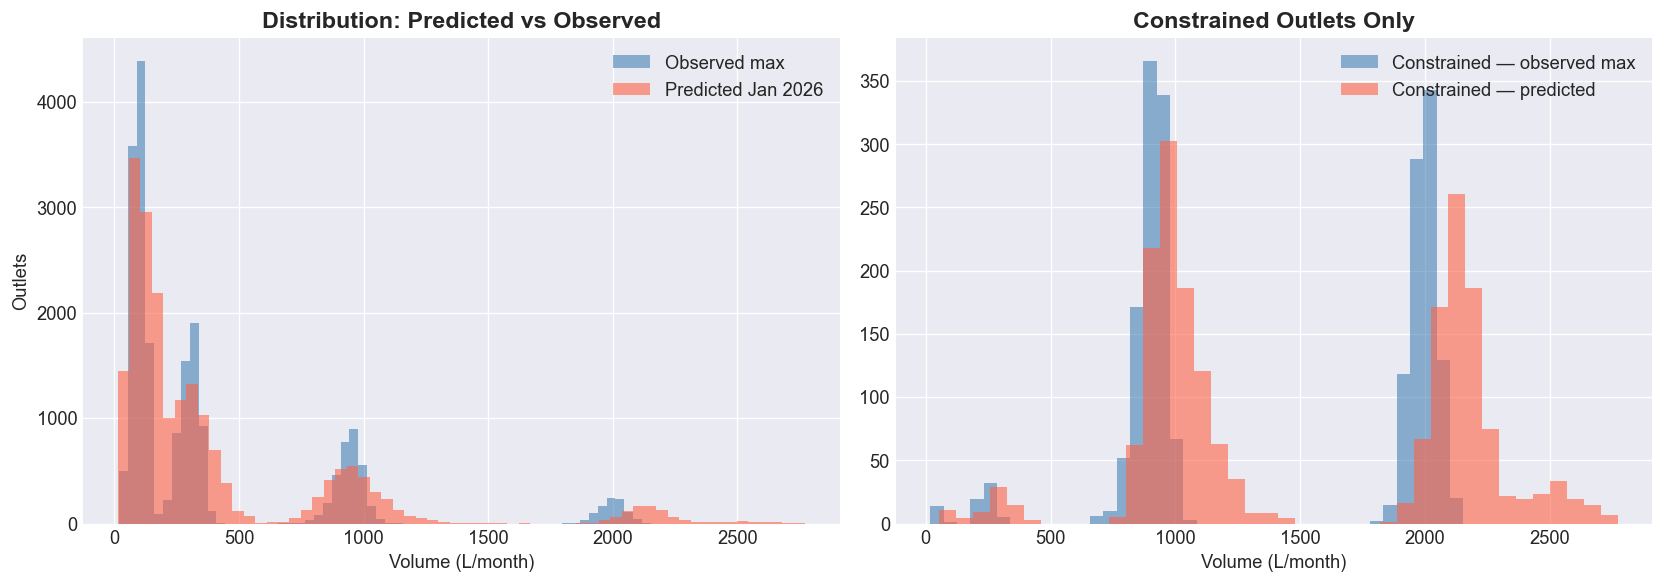


  ✓ Distribution plot saved

MODELLING COMPLETE
  Output: Data_Drifters_predictions.csv
  Outlets: 20,000
  Constrained outlets predicted above observed max: 87.8%


In [53]:
# ══════════════════════════════════════════════════════════════════════════════
# VALIDATION — Sanity Checks + Distribution Comparison
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*70}\nVALIDATION\n{'='*70}")

# 1. CV metrics (already computed above — print summary)
print(f"\n[1] 5-Fold CV on Unconstrained (XGBoost Mean):")
print(f"    RMSE: {np.mean(cv_rmse):.1f} ± {np.std(cv_rmse):.1f}")
print(f"    MAE:  {np.mean(cv_mae):.1f} ± {np.std(cv_mae):.1f}")
print(f"    R²:   {np.mean(cv_r2):.3f} ± {np.std(cv_r2):.3f}")

# 2. Constrained outlets must have predictions > their observed max
constrained_mask = output['is_constrained'] == 1
con_check = output[constrained_mask]
pct_above_obs = (con_check['predicted_jan_2026_potential']
                 > con_check['observed_max_monthly']).mean() * 100
print(f"\n[2] Constrained sanity check:")
print(f"    {pct_above_obs:.1f}% of constrained outlets predicted above their observed max")
print(f"    (expect close to 100%)")

# 3. Per-group median check
print(f"\n[3] Median predicted/observed ratio by Outlet_Type × Outlet_Size:")
output_w_meta = output.merge(
    gold[['Outlet_ID', 'Outlet_Type', 'Outlet_Size']], on='Outlet_ID'
)
ratio_check = (
    output_w_meta
    .groupby(['Outlet_Type', 'Outlet_Size'])
    .apply(lambda g: (g['predicted_jan_2026_potential'] / g['observed_max_monthly']).median())
    .reset_index(name='median_pred_obs_ratio')
    .sort_values('median_pred_obs_ratio', ascending=False)
)
print(ratio_check.to_string(index=False))

# 4. Distribution plot — predicted vs observed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(output['observed_max_monthly'], bins=60,
             alpha=0.6, label='Observed max', color='steelblue')
axes[0].hist(output['predicted_jan_2026_potential'], bins=60,
             alpha=0.6, label='Predicted Jan 2026', color='tomato')
axes[0].set_title('Distribution: Predicted vs Observed')
axes[0].set_xlabel('Volume (L/month)')
axes[0].set_ylabel('Outlets')
axes[0].legend()

axes[1].hist(output.loc[constrained_mask, 'observed_max_monthly'], bins=40,
             alpha=0.6, label='Constrained — observed max', color='steelblue')
axes[1].hist(output.loc[constrained_mask, 'predicted_jan_2026_potential'], bins=40,
             alpha=0.6, label='Constrained — predicted', color='tomato')
axes[1].set_title('Constrained Outlets Only')
axes[1].set_xlabel('Volume (L/month)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{DATA_PATHS['output']}validation_distribution.png", dpi=150)
plt.show()
print(f"\n  ✓ Distribution plot saved")

print(f"\n{'='*70}")
print(f"MODELLING COMPLETE")
print(f"{'='*70}")
print(f"  Output: {output_path}")
print(f"  Outlets: {len(output):,}")
print(f"  Constrained outlets predicted above observed max: {pct_above_obs:.1f}%")
print(f"{'='*70}")

In [54]:
# ══════════════════════════════════════════════════════════════════════════════
# IMPROVEMENT 3: Marketing Budget Optimizer — LKR 5M across Western Province
# Allocates budget proportionally to potential gap, with tier-based strategy
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nIMPROVEMENT 3: Marketing Budget Optimizer\n{'='*70}")

from scipy.optimize import linprog
import pandas as pd

def optimize_marketing_budget(
    predictions_df,
    outlet_master_df,
    total_budget=5_000_000,
    min_spend=0,
    max_spend=200_000,
):
    """
    Allocate LKR 5M across Western Province outlets to maximise predicted volume uplift.
    Uses a 3-tier strategy: constrained high-gap > unconstrained high-gap > rest.
    """
    print(f"\n{'='*60}")
    print("MARKETING BUDGET OPTIMIZER — Western Province")
    print(f"{'='*60}")

    western_distributors = ['DIST_W_01', 'DIST_W_02', 'DIST_W_03']

    western = predictions_df.merge(
        outlet_master_df[['Outlet_ID', 'Distributor_ID']],
        on='Outlet_ID', how='left'
    )
    western = western[western['Distributor_ID'].isin(western_distributors)].copy()
    western = western.reset_index(drop=True)

    print(f"Western Province outlets: {len(western):,}")
    print(f"Total budget: LKR {total_budget:,.0f}")

    western['potential_gap'] = (
        western['predicted_jan_2026_potential'] - western['observed_avg_monthly']
    ).clip(lower=0)

    total_gap = western['potential_gap'].sum()
    western['roi_weight'] = western['potential_gap'] / (total_gap + 1e-9)

    # Tier 1: constrained + high gap → 50%
    # Tier 2: unconstrained + high gap → 30%
    # Tier 3: rest → 20%
    tier1 = western[(western['is_constrained'] == 1) &
                    (western['potential_gap'] > western['potential_gap'].quantile(0.7))]
    tier2 = western[(western['is_constrained'] == 0) &
                    (western['potential_gap'] > western['potential_gap'].quantile(0.5))]
    tier3 = western[~western['Outlet_ID'].isin(
        pd.concat([tier1, tier2])['Outlet_ID']
    )]

    print(f"\nTier 1 (constrained + high gap): {len(tier1):,} outlets — 50% budget")
    print(f"Tier 2 (unconstrained + high gap): {len(tier2):,} outlets — 30% budget")
    print(f"Tier 3 (remaining):                {len(tier3):,} outlets — 20% budget")

    def allocate_tier(tier_df, budget, max_per_outlet):
        if len(tier_df) == 0 or tier_df['roi_weight'].sum() == 0:
            return pd.Series(0.0, index=tier_df.index)
        raw = tier_df['roi_weight'] / tier_df['roi_weight'].sum() * budget
        capped = raw.clip(upper=max_per_outlet)
        excess = raw.sum() - capped.sum()
        if excess > 1 and (capped < max_per_outlet).any():
            not_maxed = capped < max_per_outlet
            capped[not_maxed] += (
                excess * (tier_df.loc[not_maxed, 'roi_weight'] /
                          tier_df.loc[not_maxed, 'roi_weight'].sum())
            ).clip(upper=max_per_outlet - capped[not_maxed])
        return capped

    alloc_t1 = allocate_tier(tier1, total_budget * 0.50, max_spend)
    alloc_t2 = allocate_tier(tier2, total_budget * 0.30, max_spend)
    alloc_t3 = allocate_tier(tier3, total_budget * 0.20, max_spend * 0.5)

    all_alloc = pd.concat([alloc_t1, alloc_t2, alloc_t3])
    western['trade_spend_lkr'] = western.index.map(all_alloc.to_dict()).fillna(0)
    western['trade_spend_lkr'] = (western['trade_spend_lkr'] / 100).round() * 100
    western['estimated_volume_uplift'] = (
        western['trade_spend_lkr'] / 1000 * 0.01 * western['predicted_jan_2026_potential']
    ).round(1)

    print(f"\n{'─'*60}")
    print(f"Total allocated:          LKR {western['trade_spend_lkr'].sum():>12,.0f}")
    print(f"Total est. volume uplift: {western['estimated_volume_uplift'].sum():>12,.0f} L")
    cost_per_l = western['trade_spend_lkr'].sum() / (western['estimated_volume_uplift'].sum() + 1)
    print(f"Cost per liter uplift:    LKR {cost_per_l:>12,.0f}")

    budget_out = western[['Outlet_ID', 'trade_spend_lkr']].rename(
        columns={'trade_spend_lkr': 'Trade_Spend_Allocation_LKR'}
    )
    budget_out.to_csv('output/Data_Drifters_budget_allocations.csv', index=False)
    print(f"\n✓ Saved: output/Data_Drifters_budget_allocations.csv")

    return western


# ── Load Distributor_ID from gold (has the column we need) ──────────────────
distributor_map = pd.read_csv('gold/outlet_features.csv')[['Outlet_ID', 'Distributor_ID']]

print(f"Distributor map loaded: {len(distributor_map):,} outlets")
print(f"Distributors found: {sorted(distributor_map['Distributor_ID'].unique())}")

# ── Run optimizer ────────────────────────────────────────────────────────────
budget_results = optimize_marketing_budget(
    predictions_df=output,
    outlet_master_df=distributor_map,
    total_budget=5_000_000,
    max_spend=200_000,
)

# ── Quick summary ────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")
print(f"Outlets receiving spend:  {(budget_results['trade_spend_lkr'] > 0).sum():,}")
print(f"Outlets with zero spend:  {(budget_results['trade_spend_lkr'] == 0).sum():,}")
print(f"\nSpend by Distributor:")
print(
    budget_results.groupby('Distributor_ID')['trade_spend_lkr']
    .agg(['sum', 'mean', 'count'])
    .rename(columns={'sum': 'Total LKR', 'mean': 'Avg LKR', 'count': 'Outlets'})
    .round(0)
)
print(f"\nSpend by Tier:")
print(f"  Tier 1 outlets: {budget_results[budget_results['trade_spend_lkr'] >= 100_000]['Outlet_ID'].count():,}")
print(f"  Tier 2 outlets: {budget_results[(budget_results['trade_spend_lkr'] >= 50_000) & (budget_results['trade_spend_lkr'] < 100_000)]['Outlet_ID'].count():,}")
print(f"  Tier 3 outlets: {budget_results[budget_results['trade_spend_lkr'] < 50_000]['Outlet_ID'].count():,}")


IMPROVEMENT 3: Marketing Budget Optimizer
Distributor map loaded: 20,000 outlets
Distributors found: ['DIST_C_01', 'DIST_C_02', 'DIST_C_03', 'DIST_NW_01', 'DIST_NW_02', 'DIST_S_01', 'DIST_S_02', 'DIST_W_01', 'DIST_W_02', 'DIST_W_03']

MARKETING BUDGET OPTIMIZER — Western Province
Western Province outlets: 9,000
Total budget: LKR 5,000,000

Tier 1 (constrained + high gap): 672 outlets — 50% budget
Tier 2 (unconstrained + high gap): 3,823 outlets — 30% budget
Tier 3 (remaining):                4,505 outlets — 20% budget

────────────────────────────────────────────────────────────
Total allocated:          LKR    5,002,900
Total est. volume uplift:       57,788 L
Cost per liter uplift:    LKR           87

✓ Saved: output/Data_Drifters_budget_allocations.csv

SUMMARY
Outlets receiving spend:  8,732
Outlets with zero spend:  268

Spend by Distributor:
                Total LKR  Avg LKR  Outlets
Distributor_ID                             
DIST_W_01       1701000.0    563.0     3020
DIST_W

In [55]:
# ══════════════════════════════════════════════════════════════════════════════
# IMPROVEMENT 4B & 4C: AI Agent (XAI) — Plain-English Outlet Explanations
# Uses OpenRouter (Gemma 4 31B) to explain each outlet's predicted score
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}\nIMPROVEMENT 4: AI Explanation Agent (XAI)\n{'='*70}")

import requests
import time

# ── API Key Setup ─────────────────────────────────────────────────────────────
# Option A: Environment variable (recommended)
#   export OPENROUTER_API_KEY=sk-or-...
# Option B: Paste directly (not recommended for production)
#   API_KEY = "sk-or-..."

API_KEY = "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"
if not API_KEY:
    print("  ⚠️  OPENROUTER_API_KEY not set — skipping AI explanations.")
    print("     Set it: export OPENROUTER_API_KEY=sk-or-...")
else:
    print(f"  ✓ API key loaded")


def build_outlet_context(outlet_id, gold_df, gold_enc_df, shap_vals, predictions_df, budget_df=None):
    """Gather all information about one outlet for the AI to explain."""
    outlet = gold_df[gold_df['Outlet_ID'] == outlet_id].iloc[0]
    pred   = predictions_df[predictions_df['Outlet_ID'] == outlet_id].iloc[0]
    idx    = gold_df.index[gold_df['Outlet_ID'] == outlet_id][0]

    # Use iloc position for SHAP indexing
    arr_pos = gold_df.index.get_loc(idx)
    outlet_shap = dict(zip(XGBOOST_FEATURES, shap_vals[arr_pos]))

    pos_drivers = sorted([(k, v) for k, v in outlet_shap.items() if v > 0],
                         key=lambda x: x[1], reverse=True)[:3]
    neg_drivers = sorted([(k, v) for k, v in outlet_shap.items() if v < 0],
                         key=lambda x: x[1])[:3]

    context = {
        "outlet_id":                     outlet_id,
        "outlet_type":                   outlet.get('Outlet_Type', 'Unknown'),
        "outlet_size":                   outlet.get('Outlet_Size', 'Unknown'),
        "distributor":                   outlet.get('Distributor_ID', 'Unknown'),
        "cooler_count":                  int(outlet.get('Cooler_Count', 0)),
        "is_constrained":                bool(outlet.get('is_constrained', 0)),
        "observed_avg_monthly_liters":   round(float(pred['observed_avg_monthly']), 1),
        "observed_max_monthly_liters":   round(float(pred['observed_max_monthly']), 1),
        "predicted_potential_liters":    round(float(pred['predicted_jan_2026_potential']), 1),
        "uplift_ratio":                  round(float(pred['predicted_jan_2026_potential']) /
                                               max(float(pred['observed_avg_monthly']), 1), 2),
        "seasonality_score":             round(float(pred['jan_seasonality_score']), 2),
        "growth_ratio":                  round(float(pred['growth_ratio']), 3),
        "competitor_density":            round(float(outlet.get('competitor_density', 0)), 2),
        "poi_relative_density":          round(float(outlet.get('poi_relative_density', 0)), 3),
        "top_positive_drivers":          [{"feature": k, "impact": round(v, 2)} for k, v in pos_drivers],
        "top_negative_drivers":          [{"feature": k, "impact": round(v, 2)} for k, v in neg_drivers],
    }
    if budget_df is not None and outlet_id in budget_df['Outlet_ID'].values:
        alloc = budget_df[budget_df['Outlet_ID'] == outlet_id]['Trade_Spend_Allocation_LKR'].iloc[0]
        context["recommended_trade_spend_lkr"] = int(alloc)
    return context


def generate_outlet_explanation(outlet_context, api_key):
    """Uses Gemma 4 31B via OpenRouter to generate plain-English business explanation."""

    prompt = f"""You are a beverage trade marketing analyst. Explain this outlet's sales potential
assessment to a non-technical Sales Manager in 3-4 clear sentences.

OUTLET DATA:
- Outlet: {outlet_context['outlet_id']} ({outlet_context['outlet_type']}, {outlet_context['outlet_size']})
- Distributor: {outlet_context['distributor']}
- Cooler Units: {outlet_context['cooler_count']}
- Historical average sales: {outlet_context['observed_avg_monthly_liters']:,} L/month
- Historical max sales: {outlet_context['observed_max_monthly_liters']:,} L/month
- Predicted January 2026 Potential: {outlet_context['predicted_potential_liters']:,} L/month
- Uplift factor: {outlet_context['uplift_ratio']}x above average
- Constrained outlet: {outlet_context['is_constrained']} (was supply-capped in history)
- January seasonality score: {outlet_context['seasonality_score']}
- Sales growth trend: {outlet_context['growth_ratio']}
- Nearby competition density: {outlet_context['competitor_density']}

TOP FACTORS THAT INCREASED THE PREDICTION:
{chr(10).join([f"  - {d['feature']}: +{d['impact']:.1f} L/month" for d in outlet_context['top_positive_drivers']])}

TOP FACTORS THAT DECREASED THE PREDICTION:
{chr(10).join([f"  - {d['feature']}: {d['impact']:.1f} L/month" for d in outlet_context['top_negative_drivers']])}

{'Recommended trade spend: LKR ' + str(outlet_context.get('recommended_trade_spend_lkr', 'N/A')) if outlet_context.get('recommended_trade_spend_lkr') else ''}

Write a SHORT business explanation (3-4 sentences) answering:
1. Why was this outlet given this score?
2. What is the key opportunity?
3. What should the sales team do?
Use simple language. No math jargon. Be specific and actionable."""

    response = requests.post(
        url="https://openrouter.ai/api/v1/chat/completions",
        headers={
            "Authorization": f"Bearer {api_key}",
            "Content-Type": "application/json",
        },
        json={
            "model": "google/gemma-4-31b-it:frees",
            "max_tokens": 300,
            "messages": [{"role": "user", "content": prompt}]
        }
    )

    if response.status_code != 200:
        raise Exception(f"OpenRouter error {response.status_code}: {response.text}")

    return response.json()['choices'][0]['message']['content']


def generate_all_explanations(gold_df, gold_enc_df, shap_vals, predictions_df,
                               budget_df=None, api_key=None, sample_n=None):
    """Generate AI explanations for all (or top-N) outlets."""

    outlet_ids = predictions_df['Outlet_ID'].tolist()

    if sample_n:
        top_outlets = predictions_df.nlargest(
            sample_n, 'predicted_jan_2026_potential'
        )['Outlet_ID'].tolist()
        outlet_ids = top_outlets
        print(f"  Generating explanations for top {sample_n} outlets...")

    results = []

    for i, outlet_id in enumerate(outlet_ids):
        try:
            context     = build_outlet_context(
                outlet_id, gold_df, gold_enc_df,
                shap_vals, predictions_df, budget_df
            )
            explanation = generate_outlet_explanation(context, api_key)

            results.append({
                'Outlet_ID':           outlet_id,
                'predicted_potential': context['predicted_potential_liters'],
                'ai_explanation':      explanation,
                'is_constrained':      context['is_constrained'],
            })

            if (i + 1) % 10 == 0:
                print(f"  Progress: {i+1}/{len(outlet_ids)}")

            time.sleep(1)  # Respect free tier rate limits

        except Exception as e:
            print(f"  ⚠️  Error for {outlet_id}: {e}")
            results.append({
                'Outlet_ID':      outlet_id,
                'ai_explanation': "Explanation unavailable"
            })

    explanations_df = pd.DataFrame(results)
    explanations_df.to_csv('output/outlet_ai_explanations.csv', index=False)
    print(f"\n  ✓ Saved explanations for {len(results)} outlets → output/outlet_ai_explanations.csv")

    return explanations_df


# ── Run: Generate explanations for top 20 outlets ───────────────────────────
if API_KEY:
    print("\n  Generating AI explanations for top 20 highest-potential outlets...")
    print("  Model: google/gemma-3-27b-it:free via OpenRouter\n")

    explanations = generate_all_explanations(
        gold_df       = gold,
        gold_enc_df   = gold_enc,
        shap_vals     = shap_values,
        predictions_df= output,
        budget_df     = budget_results[['Outlet_ID', 'trade_spend_lkr']].rename(
                            columns={'trade_spend_lkr': 'Trade_Spend_Allocation_LKR'}
                        ) if 'budget_results' in dir() else None,
        api_key       = API_KEY,
        sample_n      = 20,
    )

    print("\n  Sample explanation:")
    if len(explanations) > 0:
        sample = explanations.iloc[0]
        print(f"  Outlet: {sample['Outlet_ID']}")
        print(f"  Predicted: {sample['predicted_potential']:,.1f} L")
        print(f"  Explanation: {sample['ai_explanation'][:400]}")

else:
    print("  Skipped — set OPENROUTER_API_KEY to generate explanations.")
    print("  Get a free key at: https://openrouter.ai/keys")


IMPROVEMENT 4: AI Explanation Agent (XAI)
  ✓ API key loaded

  Generating AI explanations for top 20 highest-potential outlets...
  Model: google/gemma-3-27b-it:free via OpenRouter

  Generating explanations for top 20 outlets...
  Progress: 10/20
  Progress: 20/20

  ✓ Saved explanations for 20 outlets → output/outlet_ai_explanations.csv

  Sample explanation:
  Outlet: OUT_18128
  Predicted: 2,772.3 L
  Explanation: This outlet has massive untapped potential, with a predicted jump to over 2,700 liters per month because it is a large, high-traffic kiosk that has been held back by supply shortages in the past. The biggest opportunity lies in expanding the variety of products available, as a wider selection of drinks is the primary driver for growth here. To capture this, the sales team must ensure consistent st
